In [1]:
import os
from pathlib import Path
_cwd = Path.cwd().resolve()
if _cwd.name == 'notebooks' and (_cwd.parent / 'data').is_dir():
    os.chdir(_cwd.parent)
elif (_cwd / 'data').is_dir():
    os.chdir(_cwd)

In [2]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import warnings
from itertools import combinations

import interpretation.latentspace as ls
import interpretation.predictions as prds
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
import umap
from data import create_dataset, load_data
from interpretation import attentions as att
from interpretation import visualization as viz
from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerBase
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from scipy import stats
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.stats import mannwhitneyu, pearsonr, ttest_rel, wilcoxon
from sklearn.decomposition import PCA
from tabulate import tabulate
from utils.helpers import get_all_modalities_available_samples

warnings.filterwarnings("ignore")
sns.set_style("ticks")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.grid": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.labelweight": "bold",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "legend.frameon": False,
    "legend.fontsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.image_inline": True,
    "svg.fonttype": "none",
})


In [3]:
analysis_folder = 'analysis/'
file_path = 'final_results.csv'

df = pd.read_csv(os.path.join(analysis_folder, file_path))
df.head()

,model,seed,fold,combination,train_auc,val_auc,precision,recall,f1,accuracy,specificity,n_samples,tn,fp,fn,tp,model_path,selection_criteria,run_id,timestamp
0,ATAC,0,1,all_samples,0.928387,0.831579,0.894737,0.894737,0.894737,0.849057,0.733333,53,11,4,4,34,ckp/ATAC_seed0/best_ATAC_seed0_fold1_AUC_0.832...,all_samples,ATAC_seed0_fold1_all_samples,2025-10-13 01:52:06
1,ATAC,0,1,common_samples,0.928387,0.888889,0.920000,0.958333,0.938776,0.909091,0.777778,33,7,2,1,23,ckp/ATAC_seed0/best_ATAC_seed0_fold1_AUC_0.832...,all_samples,ATAC_seed0_fold1_common_samples,2025-10-13 01:52:06
2,ATAC,0,2,all_samples,0.897419,0.966667,0.974359,1.000000,0.987013,0.981132,0.933333,53,14,1,0,38,ckp/ATAC_seed0/best_ATAC_seed0_fold2_AUC_0.967...,all_samples,ATAC_seed0_fold2_all_samples,2025-10-13 01:52:06
3,ATAC,0,2,common_samples,0.897419,0.949074,0.960000,1.000000,0.979592,0.969697,0.888889,33,8,1,0,24,ckp/ATAC_seed0/best_ATAC_seed0_fold2_AUC_0.967...,all_samples,ATAC_seed0_fold2_common_samples,2025-10-13 01:52:06
4,ATAC,0,3,all_samples,0.912713,0.790541,0.795455,0.945946,0.864198,0.792453,0.437500,53,7,9,2,35,ckp/ATAC_seed0/best_ATAC_seed0_fold3_AUC_0.791...,all_samples,ATAC_seed0_fold3_all_samples,2025-10-13 01:52:06



Metric: Validation AUC (val_auc) [combination: common_samples]
  Multi  : mean = 0.9160, std = 0.0562
  RNA    : mean = 0.8529, std = 0.0879
  ATAC   : mean = 0.8639, std = 0.0739
  Flux   : mean = 0.8080, std = 0.1100


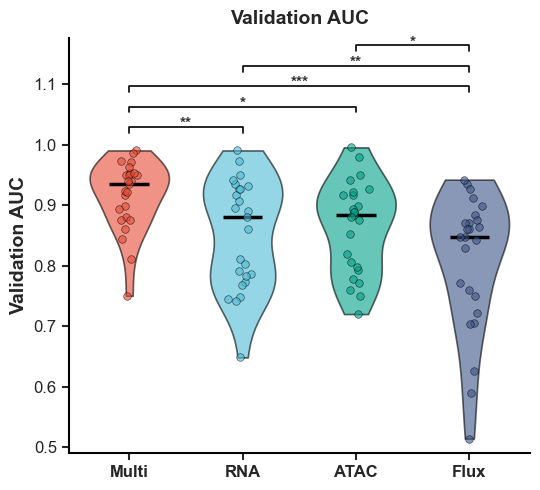

In [4]:
def add_significance_bars(ax, data_to_plot, models, y_max, y_min, test='mannwhitney'):
    comparisons = list(combinations(range(len(models)), 2))
    y_range = y_max - y_min
    h = y_range * 0.02
    y_start = y_max + y_range * 0.05
    
    sig_pairs = []
    for i, (idx1, idx2) in enumerate(comparisons):
        data1 = data_to_plot[idx1]
        data2 = data_to_plot[idx2]
        
        if test == 'mannwhitney':
            stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        elif test == 'ttest':
            stat, p_value = stats.ttest_rel(data1, data2)
        else:
            raise ValueError("test must be 'mannwhitney' or 'ttest'")
        
        if p_value < 0.001:
            sig = '***'
        elif p_value < 0.01:
            sig = '**'
        elif p_value < 0.05:
            sig = '*'
        else:
            continue
        
        sig_pairs.append((idx1, idx2, sig, p_value))
    
    max_y_sig = y_start
    for level, (idx1, idx2, sig, p_value) in enumerate(sig_pairs):
        y = y_start + (level * h * 3.5)
        x1, x2 = idx1 + 1, idx2 + 1
        
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], 'k-', lw=1.2)
        ax.text((x1 + x2) / 2, y + h*0.3, sig, ha='center', va='bottom', 
                fontsize=11, fontweight='bold')
        max_y_sig = max(max_y_sig, y + h + h*0.3)
    
    return max_y_sig

def plot_all_metrics(df, combination='common_samples', plot_type='violin', test='mannwhitney', metrics=None, print_stats=False):
    all_metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    all_metric_labels = ['Validation AUC', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Specificity']
    metric_label_map = dict(zip(all_metrics, all_metric_labels))
    if metrics is None:
        metrics_to_plot = all_metrics
        metric_labels = all_metric_labels
    elif isinstance(metrics, str):
        metrics_to_plot = [metrics]
        metric_labels = [metric_label_map.get(metrics, metrics)]
    elif isinstance(metrics, (list, tuple)):
        metrics_to_plot = list(metrics)
        metric_labels = [metric_label_map.get(m, m) for m in metrics_to_plot]
    else:
        raise ValueError("metrics must be None, a string, or a list/tuple of strings")
    df_filtered = df[df['combination'] == combination].copy()
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']
    n_metrics = len(metrics_to_plot)
    ncols = min(3, n_metrics)
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows))
    if n_metrics == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
        ax = axes[idx]
        data_to_plot = [df_filtered[df_filtered['model'] == model][metric].values for model in models]
        if print_stats:
            print(f"\nMetric: {label} ({metric}) [combination: {combination}]")
            for model, values in zip(models, data_to_plot):
                if len(values) == 0:
                    mean_val, std_val = float('nan'), float('nan')
                else:
                    mean_val, std_val = np.mean(values), np.std(values)
                print(f"  {model:7s}: mean = {mean_val:.4f}, std = {std_val:.4f}")
        if plot_type == 'violin':
            parts = ax.violinplot(data_to_plot, showmeans=False, showmedians=True, showextrema=False, widths=0.7)
            for i, pc in enumerate(parts['bodies']):
                pc.set_facecolor(colors[i])
                pc.set_alpha(0.6)
                pc.set_edgecolor('black')
                pc.set_linewidth(1.2)
            if 'cmedians' in parts:
                parts['cmedians'].set_color('black')
                parts['cmedians'].set_linewidth(2.5)
            for i, y in enumerate(data_to_plot):
                x = np.random.normal(i+1, 0.05, size=len(y))
                ax.scatter(x, y, color=colors[i], alpha=0.6, edgecolor='black', s=30, linewidth=0.5, zorder=3)
        elif plot_type == 'box':
            bp = ax.boxplot(data_to_plot, labels=models, patch_artist=True,
                           widths=0.6, showmeans=False, meanline=False,
                           medianprops=dict(color='black', linewidth=2.5),
                           boxprops=dict(linewidth=1.2),
                           whiskerprops=dict(linewidth=1.2),
                           capprops=dict(linewidth=1.2))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
        y_max = max([max(d) if len(d) > 0 else 0 for d in data_to_plot])
        y_min = min([min(d) if len(d) > 0 else 0 for d in data_to_plot])
        y_range = y_max - y_min
        max_y_sig = add_significance_bars(ax, data_to_plot, models, y_max, y_min, test=test)
        ax.set_ylim(y_min - 0.05 * y_range, max_y_sig + 0.02 * y_range)
        ax.set_xticks(np.arange(1, len(models)+1))
        ax.set_xticklabels(models, fontsize=12, fontweight='bold')
        ax.set_ylabel(label, fontsize=14, fontweight='bold')
        ax.set_title(f'{label}', fontsize=14, fontweight='bold', pad=10)
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)
        sns.despine(ax=ax, trim=False)
    for j in range(n_metrics, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    return fig

def plot_pvalue_matrices(df, combination='common_samples', test='ttest'):
    df_filtered = df[df['combination'] == combination].copy()
    
    metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    metric_labels = ['Validation AUC', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Specificity']
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        pvalue_matrix = np.zeros((len(models), len(models)))
        sig_matrix = np.empty((len(models), len(models)), dtype=object)
        
        for i, model1 in enumerate(models):
            for j, model2 in enumerate(models):
                if i == j:
                    pvalue_matrix[i, j] = 1.0
                    sig_matrix[i, j] = '-'
                else:
                    data1 = df_filtered[df_filtered['model'] == model1][metric].values
                    data2 = df_filtered[df_filtered['model'] == model2][metric].values
                    if test == 'ttest':
                        stat, p_value = stats.ttest_rel(data1, data2)
                        test_name = 't-test'
                    elif test == 'mannwhitney':
                        try:
                            stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                        except ValueError:
                            p_value = np.nan
                        test_name = 'Mann-Whitney U'
                    else:
                        raise ValueError("test must be 'ttest' or 'mannwhitney'")
                    pvalue_matrix[i, j] = p_value
                    
                    if np.isnan(p_value):
                        sig_matrix[i, j] = 'NA'
                    elif p_value < 0.001:
                        sig_matrix[i, j] = '***'
                    elif p_value < 0.01:
                        sig_matrix[i, j] = '**'
                    elif p_value < 0.05:
                        sig_matrix[i, j] = '*'
                    else:
                        sig_matrix[i, j] = 'ns'
        
        annot_matrix = np.array([[f'{pvalue_matrix[i,j]:.4f}\n{sig_matrix[i,j]}' 
                                  for j in range(len(models))] 
                                 for i in range(len(models))])
        
        mask = np.triu(np.ones_like(pvalue_matrix, dtype=bool), k=1)
        
        sns.heatmap(pvalue_matrix, annot=annot_matrix, fmt='',
                    cmap='RdYlGn_r',
                    xticklabels=models, yticklabels=models,
                    vmin=0, vmax=0.1, cbar_kws={'label': 'p-value'},
                    ax=ax, mask=mask, linewidths=1, linecolor='black',
                    annot_kws={'fontsize': 14})
        
        ax.set_title(f'{label} - P-values ({test_name})', fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Model', fontsize=11, fontweight='bold')
    
    fig.suptitle(f'Statistical Significance Between Models - {combination.replace("_", " ").title()}', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    return fig

def print_model_seeds_table(df, model='Multi', combination='common_samples'):
    df_filtered = df[(df['combination'] == combination) & (df['model'] == model)].copy()
    
    seeds = [0, 6, 42, 123, 1000]
    metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    
    metric_labels = {
        'val_auc': 'Val AUC',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1 Score',
        'accuracy': 'Accuracy',
        'specificity': 'Specificity'
    }
    
    results = []
    
    for seed in seeds:
        seed_data = df_filtered[df_filtered['seed'] == seed]
        row = {'Seed': seed}
        
        for metric in metrics:
            mean_val = seed_data[metric].mean()
            std_val = seed_data[metric].std()
            row[metric_labels[metric]] = f'{mean_val:.3f} ± {std_val:.3f}'
        
        results.append(row)
    
    results_df = pd.DataFrame(results)
    results_df = results_df.set_index('Seed')
    
    print(f"\n{'='*100}")
    print(f"{model} Model - {combination.replace('_', ' ').title()}")
    print(f"{'='*100}")
    print(results_df.to_string())
    print(f"{'='*100}\n")
    
    return results_df

def plot_confusion_matrices(df, combination='common_samples', seed=0):
    if seed is None:
        df_filtered = df[df['combination'] == combination].copy()
        seed_label = 'All Seeds'
    else:
        df_filtered = df[(df['combination'] == combination) & (df['seed'] == seed)].copy()
        seed_label = f'Seed {seed}'
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx, model in enumerate(models):
        ax = axes[idx]
        
        model_data = df_filtered[df_filtered['model'] == model]
        
        tn = model_data['tn'].sum()
        fp = model_data['fp'].sum()
        fn = model_data['fn'].sum()
        tp = model_data['tp'].sum()
        
        cm = np.array([[tn, fp], [fn, tp]])
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        labels = np.array([[f'{count:.0f}\n({norm:.2%})' 
                           for count, norm in zip(row_counts, row_norms)]
                          for row_counts, row_norms in zip(cm, cm_normalized)])
        
        sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                   xticklabels=['Dead End', 'Reprogramming'],
                   yticklabels=['Dead End', 'Reprogramming'],
                   ax=ax, cbar_kws={'label': 'Count', 'pad': 0.02},
                   linewidths=2, linecolor='white',
                   square=True,
                   annot_kws={'fontsize': 14, 'fontweight': 'bold'})
        
        total = tn + fp + fn + tp
        accuracy = (tn + tp) / total if total > 0 else 0
        ax.set_title(f'{model} (n={int(total)}, Acc={accuracy:.3f})', 
                    fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Predicted', fontsize=13, fontweight='bold', labelpad=8)
        ax.set_ylabel('True', fontsize=13, fontweight='bold', labelpad=8)
        ax.tick_params(labelsize=12, width=1.5, length=5)
        
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
        
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=11, width=1.5, length=5)
        cbar.outline.set_linewidth(1.5)
        cbar.ax.set_ylabel('Count', fontsize=12, fontweight='bold', rotation=270, labelpad=20)
    
    fig.suptitle(f'Confusion Matrices - {combination.replace("_", " ").title()} ({seed_label})', 
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    return fig

def plot_metric_by_model_seed(df, metric='val_auc', combination='common_samples'):
    df_filtered = df[df['combination'] == combination].copy()
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    seeds = [0, 6, 42, 123, 1000]
    
    metric_labels = {
        'val_auc': 'Validation AUC',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1 Score',
        'accuracy': 'Accuracy',
        'specificity': 'Specificity'
    }
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(models))
    width = 0.15
    offsets = np.arange(len(seeds)) * width - (len(seeds) - 1) * width / 2
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(seeds)))
    
    for seed_idx, seed in enumerate(seeds):
        means = []
        stds = []
        
        for model in models:
            data = df_filtered[(df_filtered['model'] == model) & (df_filtered['seed'] == seed)][metric].values
            means.append(data.mean())
            stds.append(data.std())
        
        bars = ax.bar(x + offsets[seed_idx], means, width, 
                      yerr=stds, capsize=3, 
                      label=f'Seed {seed}', 
                      color=colors[seed_idx],
                      alpha=0.8)
        
        for i, (bar, mean) in enumerate(zip(bars, means)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., 0.1,
                   f'{mean:.3f}',
                   ha='center', va='bottom', fontsize=12, rotation=90)
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel(metric_labels.get(metric, metric), fontsize=12)
    ax.set_title(f'{metric_labels.get(metric, metric)} by Model and Seed - {combination.replace("_", " ").title()}', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend(fontsize=10, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.08))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.15])
    
    plt.tight_layout()
    
    return fig

def print_metrics_table(df, combination='common_samples', seed=None):
    if seed is None:
        df_filtered = df[df['combination'] == combination].copy()
        title_seed = 'All Seeds'
    else:
        df_filtered = df[(df['combination'] == combination) & (df['seed'] == seed)].copy()
        title_seed = f'Seed {seed}'
    
    models = ['Multi', 'RNA', 'ATAC', 'Flux']
    metrics = ['val_auc', 'precision', 'recall', 'f1', 'accuracy', 'specificity']
    
    metric_labels = {
        'val_auc': 'Val AUC',
        'precision': 'Precision',
        'recall': 'Recall',
        'f1': 'F1 Score',
        'accuracy': 'Accuracy',
        'specificity': 'Specificity'
    }
    
    results = []
    metric_means = {metric: [] for metric in metrics}
    
    for model in models:
        model_data = df_filtered[df_filtered['model'] == model]
        row = {'Model': model}
        
        n_samples = int(model_data['n_samples'].sum())
        row['N Samples'] = n_samples
        
        for metric in metrics:
            mean_val = model_data[metric].mean()
            std_val = model_data[metric].std()
            row[metric_labels[metric]] = f'{mean_val:.3f} ± {std_val:.3f}'
            metric_means[metric].append(mean_val)
        
        results.append(row)
    
    results_df = pd.DataFrame(results)
    results_df = results_df.set_index('Model')
    
    print(f"\n{'='*110}")
    print(f"Metrics Summary - {combination.replace('_', ' ').title()} - {title_seed}")
    print(f"{'='*110}")
    print(results_df.to_string())
    print(f"{'='*110}\n")
    
    for metric in metrics:
        max_idx = np.argmax(metric_means[metric])
        print(f"Best {metric_labels[metric]}: {models[max_idx]}")
    print()
    
    return results_df

fig1 = plot_all_metrics(df, combination='common_samples', plot_type='violin', test='ttest', metrics=['val_auc'], print_stats=True)
plt.show()

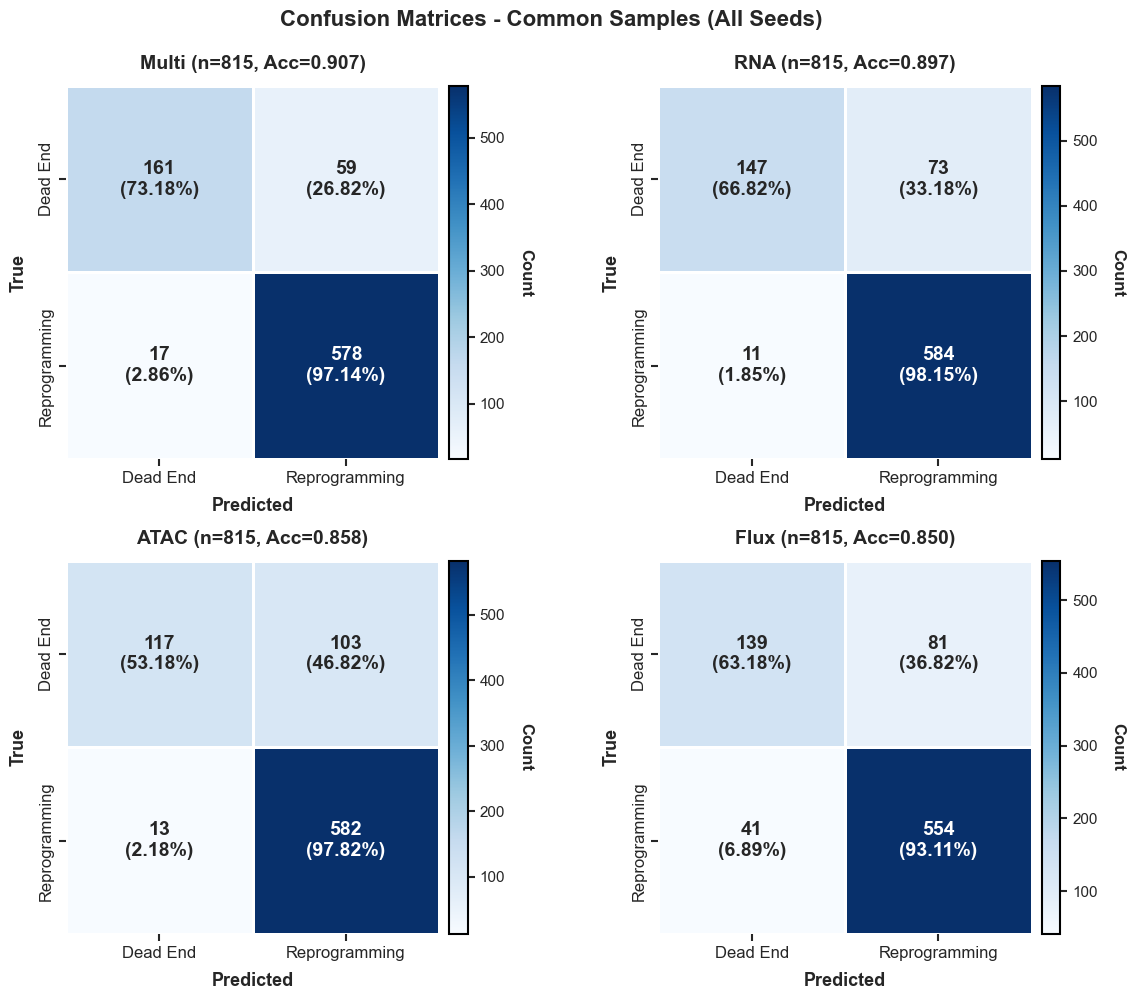

In [9]:
fig = plot_confusion_matrices(df, combination='common_samples', seed=None)
plt.show()

In [10]:
table = print_metrics_table(df, combination='all_samples', seed=0)


Metrics Summary - All Samples - Seed 0
       N Samples        Val AUC      Precision         Recall       F1 Score       Accuracy    Specificity
Model                                                                                                     
Multi       2110  0.921 ± 0.020  0.913 ± 0.025  0.937 ± 0.017  0.924 ± 0.011  0.893 ± 0.017  0.795 ± 0.068
RNA         2008  0.920 ± 0.014  0.889 ± 0.021  0.959 ± 0.015  0.923 ± 0.009  0.888 ± 0.014  0.725 ± 0.059
ATAC         265  0.880 ± 0.071  0.856 ± 0.101  0.963 ± 0.044  0.903 ± 0.060  0.849 ± 0.102  0.571 ± 0.365
Flux        2008  0.831 ± 0.010  0.849 ± 0.053  0.855 ± 0.087  0.847 ± 0.019  0.787 ± 0.020  0.632 ± 0.204

Best Val AUC: Multi
Best Precision: Multi
Best Recall: ATAC
Best F1 Score: Multi
Best Accuracy: Multi
Best Specificity: Multi



In [11]:
with open('objects/mutlimodal_dataset.pkl', 'rb') as f:
    md = pickle.load(f)
X, y_label = md['X'], md['y_label'], 
b, df_indices, pcts = md['b'], md['df_indices'], md['pcts']

feature_names = list(X[0].columns) + ['batch_rna'] + list(X[1].columns) + \
                    ['batch_atac'] + list(X[2].columns) + ['batch_flux']
y_number = torch.tensor([{'reprogramming':1, 'dead-end':0}[i] for i in 
                                list(y_label)], dtype=torch.float32)
multimodal_dataset = create_dataset.MultiModalDataset(X, b, y_number,  
                                                df_indices, pcts, y_label)
multimodal_dataset_all = get_all_modalities_available_samples(multimodal_dataset)
fold_results_path = os.path.join('objects', 'fold_results_multi.pkl')
with open(fold_results_path, 'rb') as f:
    fold_results = pickle.load(f)

def replace_fold_results_path(fold_results):
    for fold in fold_results:
        curr_path = fold['best_model_path']
        model_dir = os.path.basename(os.path.dirname(curr_path))
        ckpt_name = os.path.basename(curr_path)

        fold_token = next((part for part in ckpt_name.split('_') if part.startswith('fold')), '')
        fold_idx = ''.join(ch for ch in fold_token if ch.isdigit())
        if fold_idx:
            clean_ckpt_name = f'multi_seed0_fold{fold_idx}.pth'
        else:
            clean_ckpt_name = ckpt_name

        fold['best_model_path'] = os.path.join('ckp', model_dir, clean_ckpt_name)
    return fold_results

fold_results = replace_fold_results_path(fold_results)


share_config = {
    "d_model": 128,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.0,
}

with open('data/datasets/rna_labelled.pkl', 'rb') as f:
    adata_RNA_labelled = pickle.load(f)
rna_dataset, _, _ = create_dataset.get_cls_dataset(
        data=adata_RNA_labelled,
        batch_key="batch_no",
        label_key="label", 
        pct_key="pct",
        filter_pcts=0.0,
        data_dtype=torch.int32
    )
with open('data/datasets/atac_labelled.pkl', 'rb') as f:
    adata_ATAC_labelled = pickle.load(f)
atac_dataset, _, _ = create_dataset.get_cls_dataset(
            data=adata_ATAC_labelled,
            batch_key="batch_no",
            label_key="label",
            pct_key="pct", 
            filter_pcts=0.0,
            data_dtype=torch.float32
        )

fluxes = load_data.load_flux("data/datasets/flux_labelled_11nov.csv", prefix="flux_un",
                                                                        clone_info=True, 
                                                                        clone_path="data/datasets/clones.csv", 
                                                                        scale=True,
                                                                        flux_metadata_path="data/datasets/metabolic_model_metadata.csv")
adata_Flux_labelled, _, bi_labelled, _, flux_labels, pcts_flux = fluxes

flux_dataset, _, _ = create_dataset.get_cls_dataset(
    data=(adata_Flux_labelled, flux_labels, bi_labelled, pcts_flux),
    batch_key=None,
    label_key=None,
    pct_key=None,
    filter_pcts=0.0,
    data_dtype=torch.float32
)
with open('objects/degs.pkl', 'rb') as f:
    degs = pickle.load(f)
df_rna_degs, df_atac_degs, df_flux_degs = degs[0], degs[1], degs[2]
   
model_config_rna = {"vocab_size": 5914, "seq_len": X[0].shape[1]}
model_config_atac = {"vocab_size": 1, "seq_len": X[1].shape[1]}
model_config_flux = {"vocab_size": 1, "seq_len": X[2].shape[1]}
model_config_multi = {"d_model": 128, "n_heads_cls": 8, "d_ff_cls": 16}

model_config = {"Share": share_config, "RNA": model_config_rna, "ATAC": model_config_atac, 
                "Flux": model_config_flux, "Multi": model_config_multi}

In [12]:
df_samples = prds.get_sample_predictions_dataframe(
    model_type='Multi',
    multimodal_dataset=multimodal_dataset,
    fold_results=fold_results,
    model_config=model_config,
    device='cpu',
    batch_size=32,
    threshold=0.5
)

Processing 5 folds...
  Fold 1: 422 samples processed
  Fold 2: 422 samples processed
  Fold 3: 422 samples processed
  Fold 4: 422 samples processed
  Fold 5: 422 samples processed

Total samples: 2110
Correct predictions: 1885 (89.34%)
Mean absolute error: 0.1560


In [13]:
common_samples = False
ls_v, labels, preds = ls.get_latent_space("Multi", fold_results, 
                            multimodal_dataset, model_config, 'cpu', common_samples=common_samples)

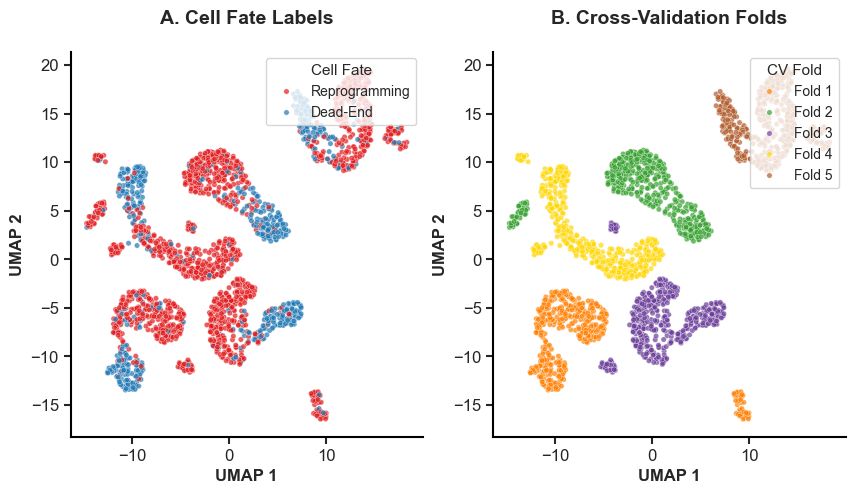

In [14]:
def plot_latent_space(ls_v, labels, preds, fold_results, common_samples=False, plot_type='umap'):
    if plot_type == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=0, n_neighbors=30, min_dist=1)
        reduced_latent_space = reducer.fit_transform(ls_v)
    elif plot_type == 'pca':
        pca = PCA(n_components=2)
        reduced_latent_space = pca.fit_transform(ls_v)
        explained_variance = pca.explained_variance_ratio_
        print(f"Variance explained by Component 1: {explained_variance[0]:.2f}")
        print(f"Variance explained by Component 2: {explained_variance[1]:.2f}")
        print(f"Total variance explained: {sum(explained_variance):.2f}")

    fold_assignment = []
    for fold_idx, fold in enumerate(fold_results):
        if common_samples:
            val_idx = fold['common_val_indices']
        else:
            val_idx = fold['val_idx']
        fold_assignment.extend([f'Fold {fold_idx + 1}'] * len(val_idx))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

    labels_mapped = ['Reprogramming' if label == 1.0 else 'Dead-End' for label in labels.flatten()]
    df_labels = pd.DataFrame({
        'UMAP 1': reduced_latent_space[:, 0],
        'UMAP 2': reduced_latent_space[:, 1],
        'Cell Fate': labels_mapped
    })

    colors_fate = ['#E31A1C', '#1F78B4']  # Red for Dead-End, Blue for Reprogramming
    sns.scatterplot(data=df_labels, x='UMAP 1', y='UMAP 2', hue='Cell Fate', 
                    palette=colors_fate, s=15, alpha=0.7, ax=ax1, rasterized=True)
    ax1.set_title('A. Cell Fate Labels', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xlabel('UMAP 1', fontsize=12)
    ax1.set_ylabel('UMAP 2', fontsize=12)
    ax1.legend(title='Cell Fate', title_fontsize=11, fontsize=10, 
            loc='upper right', frameon=True)

    df_folds = pd.DataFrame({
        'UMAP 1': reduced_latent_space[:, 0],
        'UMAP 2': reduced_latent_space[:, 1],
        'Fold': fold_assignment
    })

    colors_folds = ['#FF7F00', '#33A02C', '#6A3D9A', '#FFD700', '#B15928']
    sns.scatterplot(data=df_folds, x='UMAP 1', y='UMAP 2', hue='Fold', 
                    palette=colors_folds[:len(fold_results)], s=15, alpha=0.7, ax=ax2)
    ax2.set_title('B. Cross-Validation Folds', fontsize=14, fontweight='bold', pad=20)
    ax2.set_xlabel('UMAP 1', fontsize=12)
    ax2.set_ylabel('UMAP 2', fontsize=12)
    ax2.legend(title='CV Fold', title_fontsize=11, fontsize=10, 
            loc='upper right', frameon=True)

    for ax in [ax1, ax2]:
        ax.set_axisbelow(True)
        ax.set_aspect('equal', adjustable='box')

    return fig

fig = plot_latent_space(ls_v, labels, preds, fold_results, common_samples=common_samples, plot_type='umap')
plt.show()

In [15]:
with open('objects/fi_shift_flux.pkl', 'rb') as f:
    fi_shift_flux = pickle.load(f)

with open('objects/fi_shift_atac.pkl', 'rb') as f:
    fi_shift_atac = pickle.load(f)

with open('objects/fi_shift_rna.pkl', 'rb') as f:
    fi_shift_rna = pickle.load(f)


In [16]:
all_indices = df_samples.index.tolist()
de_preds_indices = df_samples[df_samples["predicted_class"] == "dead-end"].index.tolist()
re_preds_indices = df_samples[df_samples["predicted_class"] == "reprogramming"].index.tolist()

all_layers_attentions_all = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                            indices=all_indices, average_heads=False, return_flow_attention=True)
all_layers_attentions_dead_end = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                 indices=de_preds_indices, average_heads=False, return_flow_attention=True)
all_layers_attentions_reprogramming = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                      indices=re_preds_indices, average_heads=False, return_flow_attention=True)

cls_layer_attentions_all = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                            indices=all_indices, average_heads=False, return_flow_attention=False)
cls_layer_attentions_dead_end = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                 indices=de_preds_indices, average_heads=False, return_flow_attention=False)
cls_layer_attentions_reprogramming = att.analyze_cls_attention("Multi", fold_results, multimodal_dataset, model_config, device='cpu', 
                                                      indices=re_preds_indices, average_heads=False, return_flow_attention=False)

rollout_attention_all = att.multimodal_attention_rollout(all_layers_attentions_all)
rollout_attention_dead_end = att.multimodal_attention_rollout(all_layers_attentions_dead_end)
rollout_attention_reprogramming = att.multimodal_attention_rollout(all_layers_attentions_reprogramming)

rollout_attention_all = rollout_attention_all / rollout_attention_all.sum(dim=-1, keepdim=True)
rollout_attention_dead_end = rollout_attention_dead_end / rollout_attention_dead_end.sum(dim=-1, keepdim=True)
rollout_attention_reprogramming = rollout_attention_reprogramming / rollout_attention_reprogramming.sum(dim=-1, keepdim=True)

cls_layer_attentions_all_avg = cls_layer_attentions_all.mean(axis=1) # Average over heads
cls_layer_attentions_dead_end_avg = cls_layer_attentions_dead_end.mean(axis=1)
cls_layer_attentions_reprogramming_avg = cls_layer_attentions_reprogramming.mean(axis=1)

(163, 1998) all_attention.shape
(36, 1998) dead_end_attention.shape
(127, 1998) reprogramming_attention.shape


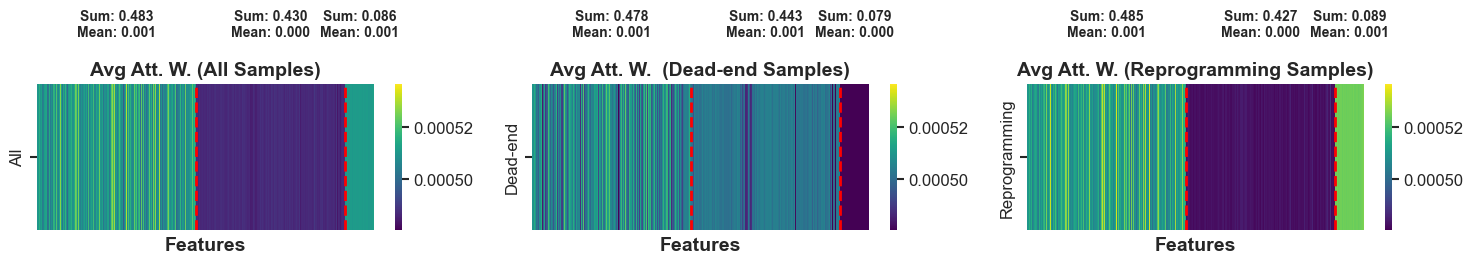

torch.Size([163, 1998]) all_attention.shape
torch.Size([36, 1998]) dead_end_attention.shape
torch.Size([127, 1998]) reprogramming_attention.shape


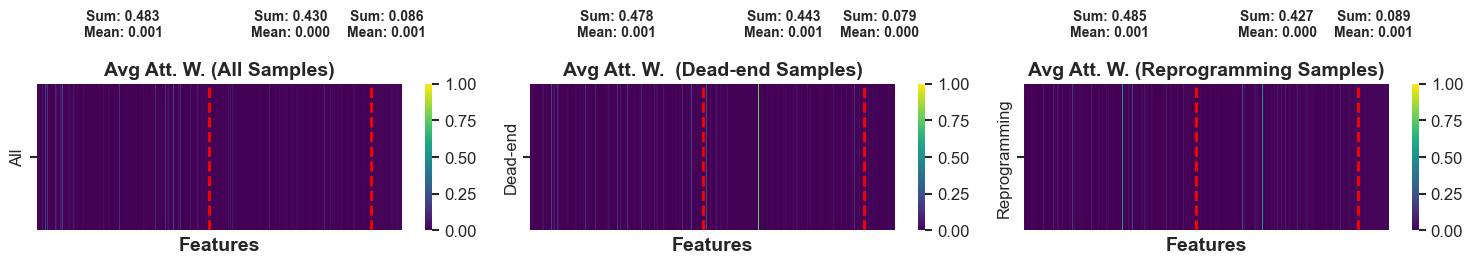

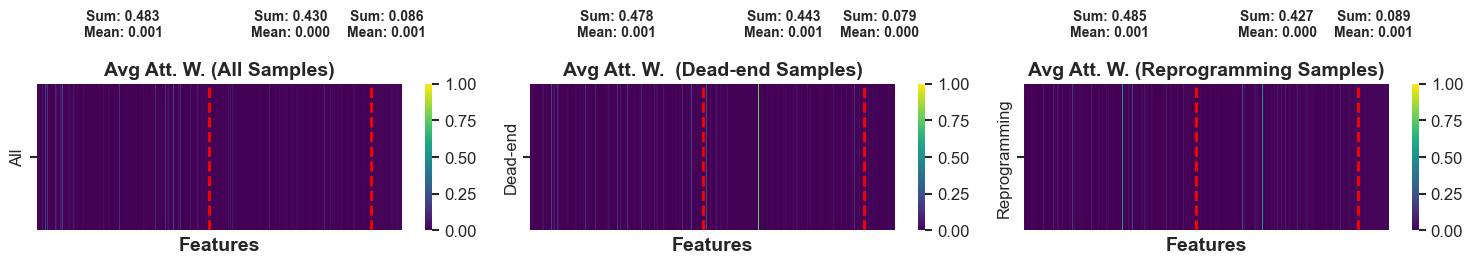

In [17]:
f = viz.plot_att_weights(cls_layer_attentions_all_avg, cls_layer_attentions_dead_end_avg, 
                        cls_layer_attentions_reprogramming_avg, 
                     feature_names=feature_names, print_top_features=False, top_n=5, scale_weights=False,
                     use_mean_contribution='sum', fix_scale=True)
viz.plot_att_weights(rollout_attention_all, rollout_attention_dead_end, rollout_attention_reprogramming, 
                     feature_names=feature_names, print_top_features=False, top_n=5, scale_weights=True,
                     use_mean_contribution='sum')

Mean attention weight values per modality and per condition:
All - RNA: mean=0.00051129, std=0.00001925
All - ATAC: mean=0.00048696, std=0.00001862
All - Flux: mean=0.00051095, std=0.00002896
Dead-end - RNA: mean=0.00050599, std=0.00002776
Dead-end - ATAC: mean=0.00050151, std=0.00002780
Dead-end - Flux: mean=0.00046453, std=0.00001951
Reprogramming - RNA: mean=0.00051280, std=0.00001572
Reprogramming - ATAC: mean=0.00048284, std=0.00001221
Reprogramming - Flux: mean=0.00052411, std=0.00001358


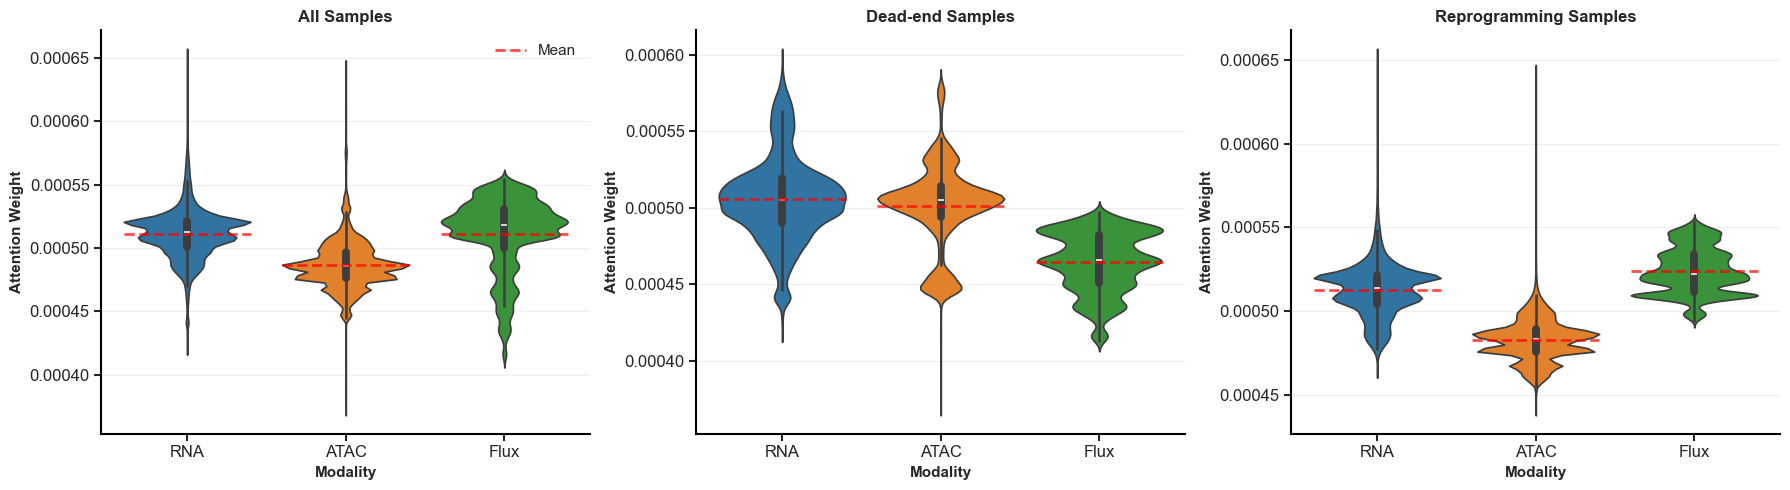

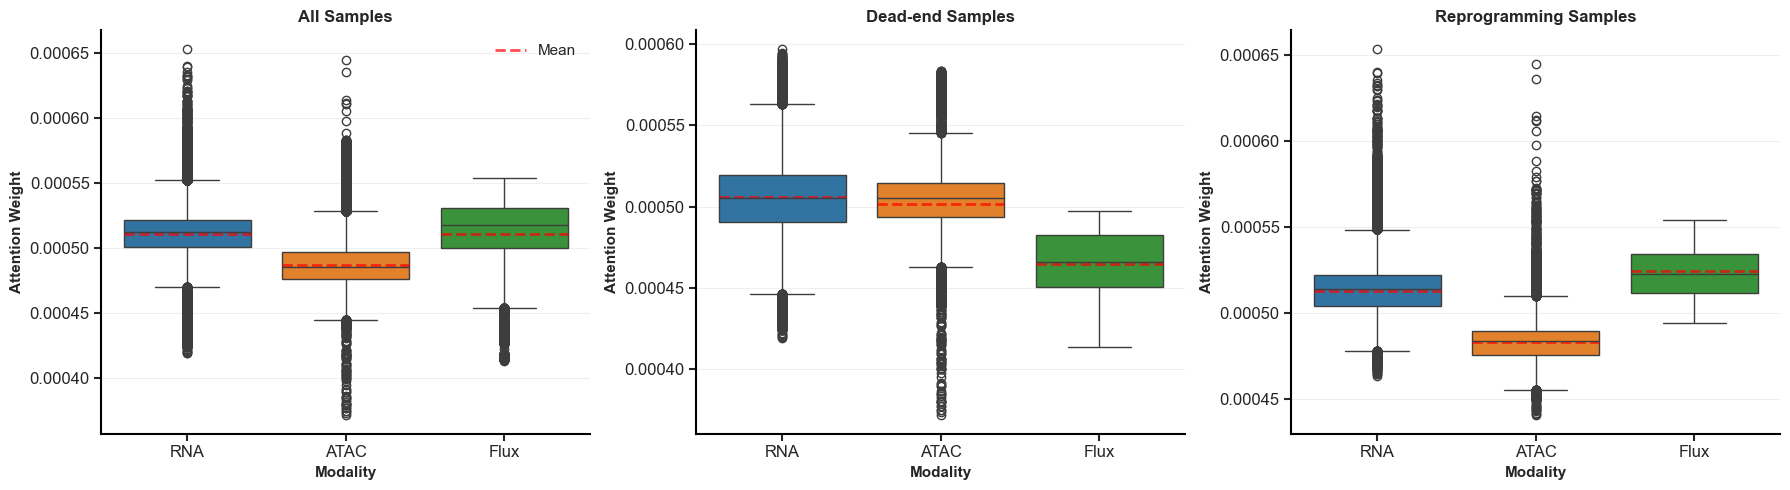

In [18]:
fig = viz.plot_att_weights_distribution(cls_layer_attentions_all_avg, cls_layer_attentions_dead_end_avg, cls_layer_attentions_reprogramming_avg, feature_names=feature_names, print_means=True)
fig = viz.plot_att_weights_distribution(cls_layer_attentions_all_avg, cls_layer_attentions_dead_end_avg, cls_layer_attentions_reprogramming_avg, feature_names=feature_names, plot_type='box')

In [19]:
top_n_print = 6

top_n_get = None
fi_att_rna = att.get_top_features(rollout_attention_all[:, :945], feature_names[:945], modality='RNA', top_n=top_n_get) # RNA
fi_att_atac = att.get_top_features(rollout_attention_all[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_get) # ATAC
fi_att_flux = att.get_top_features(rollout_attention_all[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_get) # Flux

fi_att_rna_de = att.get_top_features(rollout_attention_dead_end[:, :945], feature_names[:945], modality='RNA', top_n=top_n_get) # RNA
fi_att_atac_de = att.get_top_features(rollout_attention_dead_end[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_get) # ATAC
fi_att_flux_de = att.get_top_features(rollout_attention_dead_end[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_get) # Flux

fi_att_rna_re = att.get_top_features(rollout_attention_reprogramming[:, :945], feature_names[:945], modality='RNA', top_n=top_n_get) # RNA
fi_att_atac_re = att.get_top_features(rollout_attention_reprogramming[:, 945:945+884], feature_names[945:945+884], modality='ATAC', top_n=top_n_get) # ATAC
fi_att_flux_re = att.get_top_features(rollout_attention_reprogramming[:, 945+884:], feature_names[945+884:], modality='Flux', top_n=top_n_get) # Flux


Metrics summary (mean ± std) for each model and MLM status:
| Model               | with_without_MLM   | AUC             | Precision   | Recall   | F1   | Accuracy   | Specificity   |   n_samples |   n_samples |
|---------------------|--------------------|-----------------|-------------|----------|------|------------|---------------|-------------|-------------|
| Multi (With MLM)    | With MLM           | 0.9252 ± 0.0138 | -           | -        | -    | -          | -             |           5 |           5 |
| Multi (Without MLM) | Without MLM        | 0.8921 ± 0.0195 | -           | -        | -    | -          | -             |           5 |           5 |
| RNA (With MLM)      | With MLM           | 0.9139 ± 0.0148 | -           | -        | -    | -          | -             |           5 |           5 |
| RNA (Without MLM)   | Without MLM        | 0.8588 ± 0.0186 | -           | -        | -    | -          | -             |           5 |           5 |
| ATAC (With MLM)     | With

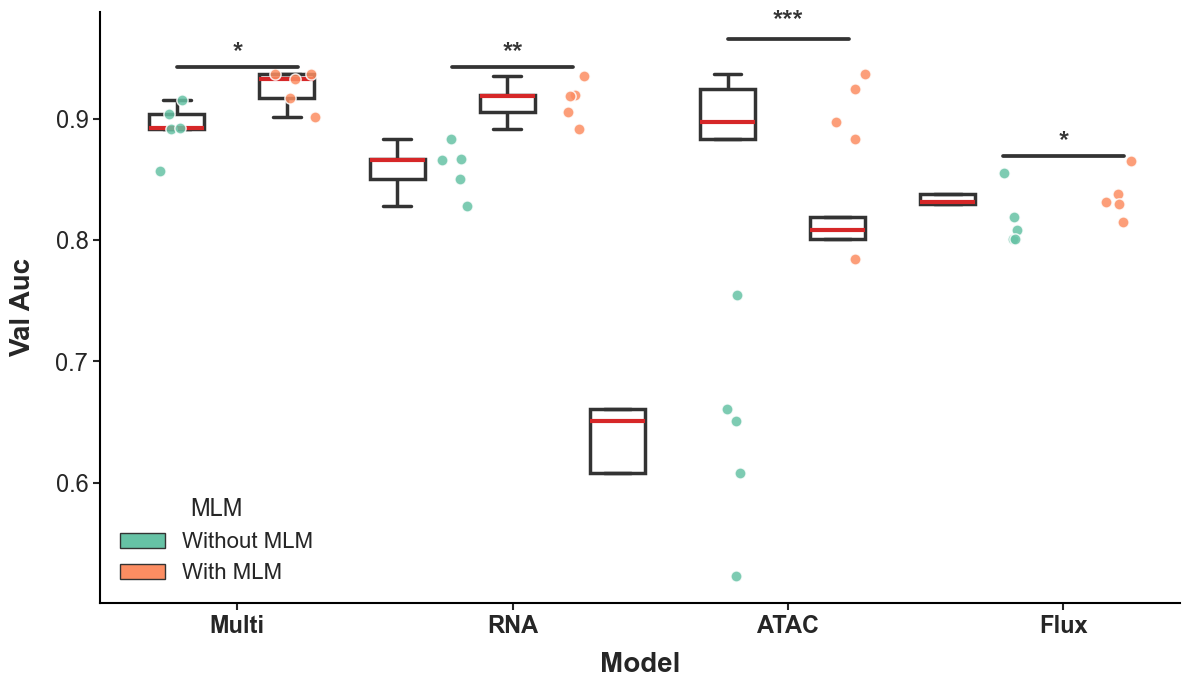

In [21]:
def create_combined_feature_dataframe(fi_shift_rna, fi_shift_atac, fi_shift_flux,
                                      fi_att_rna, fi_att_atac, fi_att_flux,
                                      df_rna_degs=None, df_atac_degs=None, df_flux_degs=None,
                                      remove_batch=True):
    
    def process_modality(shift_list, att_list, degs_df, modality_name):
        shift_df = pd.DataFrame(shift_list, columns=["feature", "importance_shift"]).reset_index()
        shift_df.rename(columns={"index": "rank_shift_in_modal"}, inplace=True)
        shift_df["rank_shift_in_modal"] += 1
        
        att_df = pd.DataFrame(att_list, columns=["feature", "importance_att"]).reset_index()
        att_df.rename(columns={"index": "rank_att_in_modal"}, inplace=True)
        att_df["rank_att_in_modal"] += 1
        
        combined_df = pd.merge(shift_df, att_df, on="feature", how="outer")
        
        if degs_df is not None:
            combined_df = pd.merge(combined_df, degs_df, on="feature", how="left")
        
        combined_df["modality"] = modality_name
        
        return combined_df
    
    rna_df = process_modality(fi_shift_rna, fi_att_rna, df_rna_degs, "RNA")
    atac_df = process_modality(fi_shift_atac, fi_att_atac, df_atac_degs, "ATAC")
    flux_df = process_modality(fi_shift_flux, fi_att_flux, df_flux_degs, "Flux")
    
    all_features_df = pd.concat([rna_df, atac_df, flux_df], ignore_index=True)
    
    if remove_batch:
        all_features_df = all_features_df[~all_features_df["feature"].str.contains("batch", na=False)]
    
    max_rank_modal = max(all_features_df["rank_att_in_modal"].max(), all_features_df["rank_shift_in_modal"].max())
    all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]] = all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]].fillna(max_rank_modal + 1)
    all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]] = all_features_df[["rank_att_in_modal", "rank_shift_in_modal"]].astype("int32")
    
    all_features_df[["importance_att", "importance_shift"]] = all_features_df[["importance_att", "importance_shift"]].fillna(0).astype("float64")
    
    all_features_df["rank_shift"] = all_features_df["importance_shift"].rank(ascending=False, method="first").astype("int32")
    all_features_df["rank_att"] = all_features_df["importance_att"].rank(ascending=False, method="first").astype("int32")
    
    all_features_df["mean_rank"] = all_features_df[["rank_att", "rank_shift"]].mean(axis=1)
    
    top_th = int(all_features_df.shape[0] * 0.1) + 1
    all_features_df["top_10_pct"] = all_features_df.apply(
        lambda row: "both" if row["rank_shift"] <= top_th and row["rank_att"] <= top_th else 
        ("shift" if row["rank_shift"] <= top_th else ("att" if row["rank_att"] <= top_th else "None")),
        axis=1
    )
    
    float_cols = [col for col in all_features_df.columns if col.startswith(('log_fc', 'mean_', 'std_', 'pval_'))]
    if float_cols:
        all_features_df[float_cols] = all_features_df[float_cols].round(6)
    
    all_features_df["importance_att"] = all_features_df["importance_att"].round(6)
    all_features_df["importance_shift"] = all_features_df["importance_shift"].round(6)
    all_features_df = all_features_df.sort_values(by="mean_rank", ascending=True)
    
    all_features_df = all_features_df[['mean_rank', 'feature', 'rank_shift', 'rank_att', 'rank_shift_in_modal', 
        'rank_att_in_modal', 'modality', 'importance_shift', 'importance_att', 'top_10_pct', 
        'mean_de', 'mean_re', 'std_de', 'std_re', 'pval', 'pval_adj', 'log_fc', 'group',
        'pval_adj_log', 'mean_diff', 'pathway', 'module']]
    
    return all_features_df

df_features = create_combined_feature_dataframe(fi_shift_rna, fi_shift_atac,
                                        fi_shift_flux, fi_att_rna, fi_att_atac, fi_att_flux,
                                        df_rna_degs, df_atac_degs, df_flux_degs)

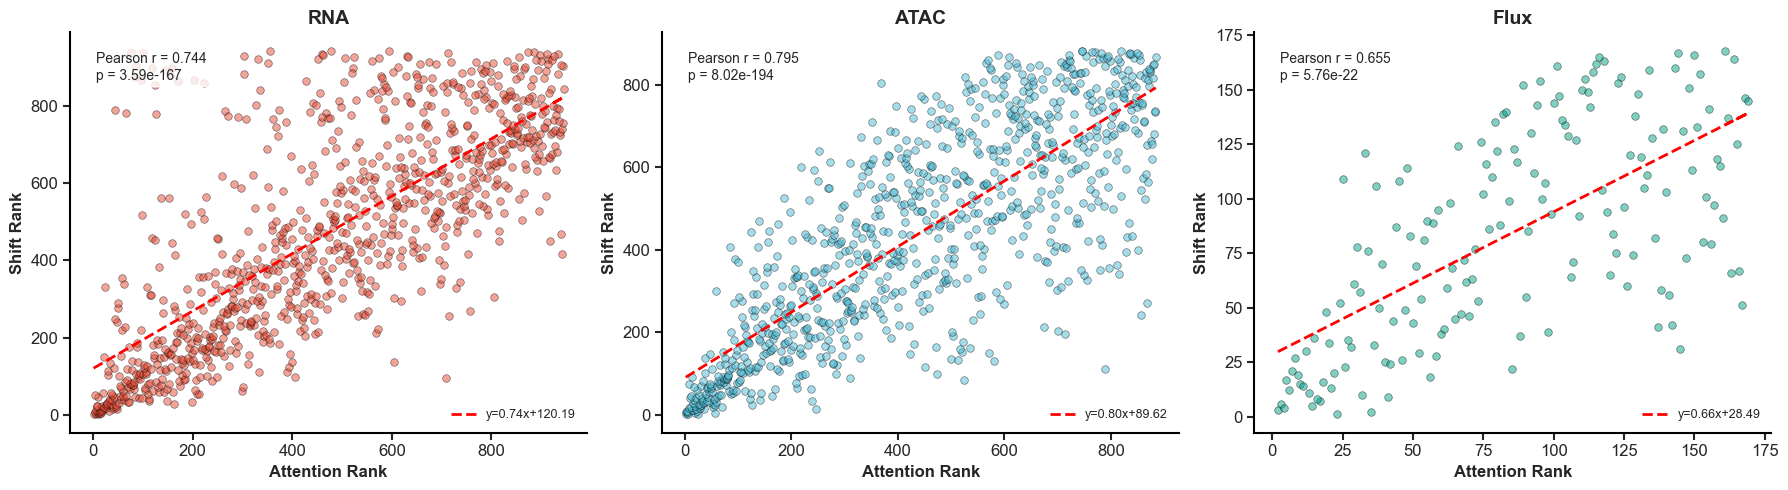

In [22]:
def plot_rank_correlation(rna_df, atac_df, flux_df, figsize=(18, 5)):
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    dfs = [rna_df, atac_df, flux_df]
    titles = ['RNA', 'ATAC', 'Flux']
    colors = ['#E64B35', '#4DBBD5', '#00A087']
    
    for idx, (df, title, color) in enumerate(zip(dfs, titles, colors)):
        ax = axes[idx]
        
        df_clean = df[['rank_att_in_modal', 'rank_shift_in_modal']].dropna()
        x = df_clean['rank_att_in_modal']
        y = df_clean['rank_shift_in_modal']
        
        ax.scatter(x, y, alpha=0.5, s=30, color=color, edgecolors='black', linewidth=0.5, rasterized=True)
        
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", linewidth=2, label=f'y={z[0]:.2f}x+{z[1]:.2f}')
        
        pearson_corr, pearson_p = pearsonr(x, y)
        
        textstr = f'Pearson r = {pearson_corr:.3f}\np = {pearson_p:.2e}'
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Attention Rank', fontsize=12, fontweight='bold')
        ax.set_ylabel('Shift Rank', fontsize=12, fontweight='bold')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    
    return fig
rna_combined_df = df_features[df_features.modality == "RNA"]
atac_combined_df = df_features[df_features.modality == "ATAC"]
flux_combined_df = df_features[df_features.modality == "Flux"]
fig = plot_rank_correlation(rna_combined_df, atac_combined_df, flux_combined_df)
plt.show()

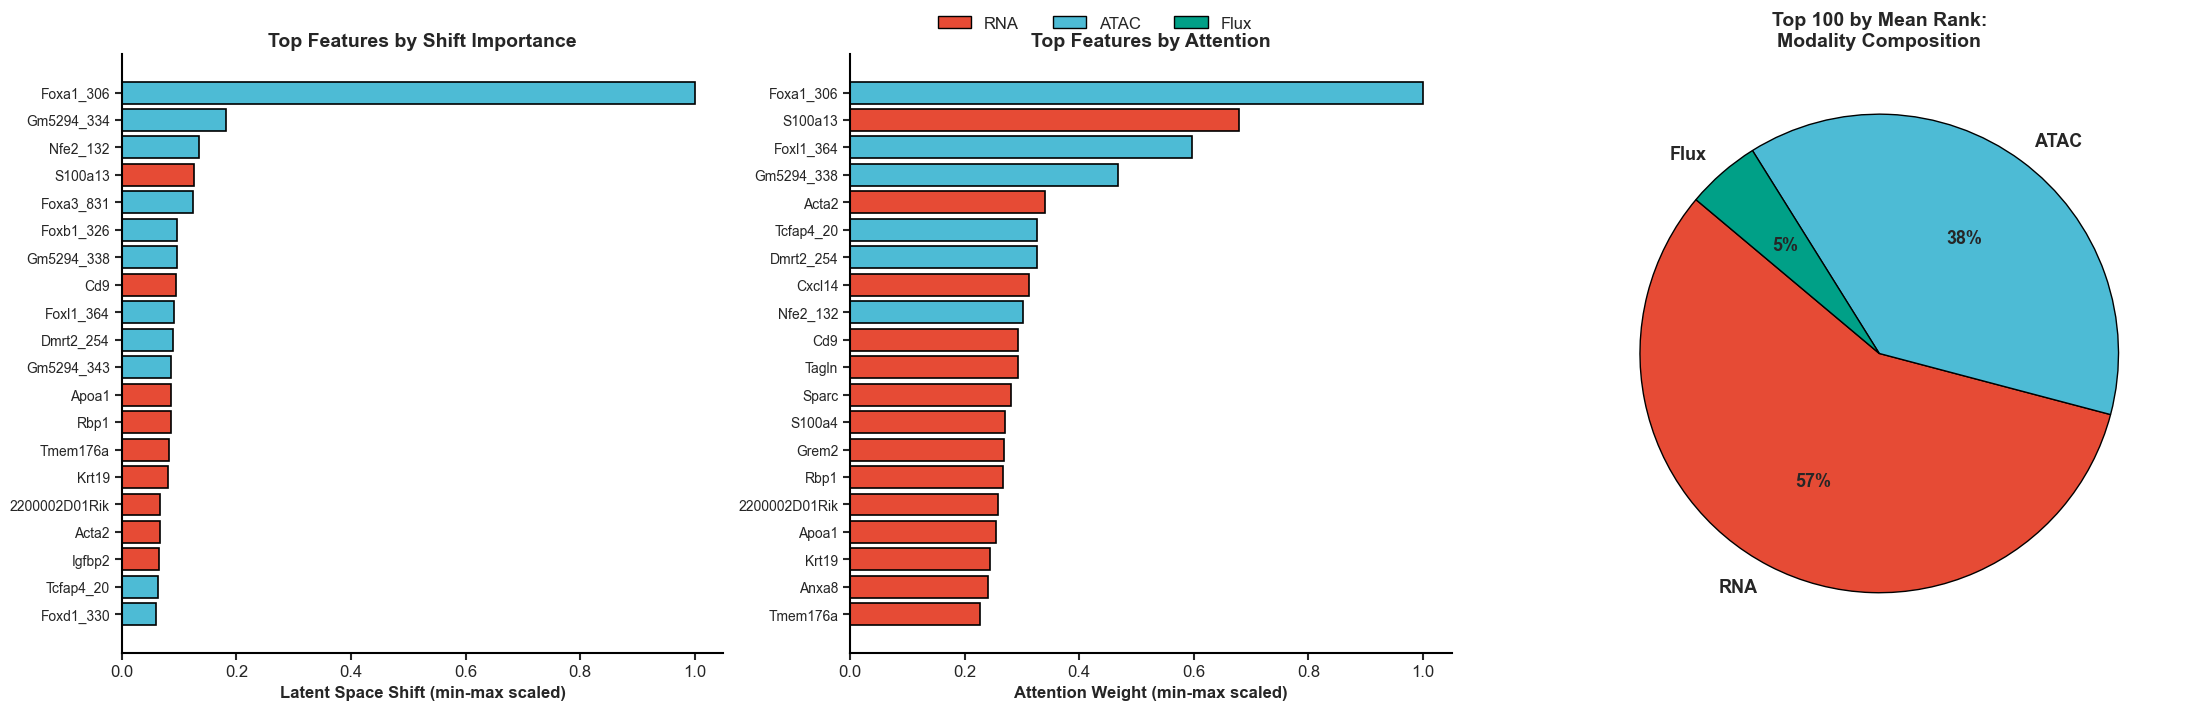

In [23]:
def plot_top_features_shift_attention(df_features, top_n=20, top_n_pie=100, print_top_features=False):
    df_features = df_features.copy()
    for col in ['importance_shift', 'importance_att']:
        min_val = df_features[col].min()
        max_val = df_features[col].max()
        if max_val > min_val:
            df_features[col + '_norm'] = (df_features[col] - min_val) / (max_val - min_val)
        else:
            df_features[col + '_norm'] = 0.0

    shift_top = df_features.nlargest(top_n, 'importance_shift')[['feature', 'importance_shift_norm', 'modality']]
    att_top = df_features.nlargest(top_n, 'importance_att')[['feature', 'importance_att_norm', 'modality']]
    mean_rank_top_for_pie = df_features.nsmallest(top_n_pie, 'mean_rank')[['feature', 'mean_rank', 'modality']]

    df_features['rank_shift'] = df_features['importance_shift'].rank(ascending=False, method='min')
    df_features['rank_att'] = df_features['importance_att'].rank(ascending=False, method='min')
    df_features['rank_mean'] = df_features['mean_rank'].rank(ascending=True, method='min')
    mean_rank_top = df_features.nsmallest(top_n, 'mean_rank')[['feature', 'mean_rank', 'modality', 'rank_shift', 'rank_att', 'rank_mean']].copy()

    color_map = {'RNA': '#E64B35', 'ATAC': '#4DBBD5', 'Flux': '#00A087'}
    pie_labels = ['RNA', 'ATAC', 'Flux']

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    ax1, ax2, ax3 = axes

    shift_features = shift_top['feature'].tolist()
    shift_values = shift_top['importance_shift_norm'].tolist()
    shift_colors = [color_map[m] for m in shift_top['modality']]
    y_pos_shift = np.arange(len(shift_features))
    ax1.barh(y_pos_shift, shift_values, color=shift_colors, edgecolor='black', linewidth=1.2)
    ax1.set_yticks(y_pos_shift)
    ax1.set_yticklabels(shift_features, fontsize=10)
    ax1.invert_yaxis()
    ax1.set_xlabel('Latent Space Shift (min-max scaled)', fontsize=12, fontweight='bold')
    ax1.set_title('Top Features by Shift Importance', fontsize=14, fontweight='bold')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    att_features = att_top['feature'].tolist()
    att_values = att_top['importance_att_norm'].tolist()
    att_colors = [color_map[m] for m in att_top['modality']]
    y_pos_att = np.arange(len(att_features))
    ax2.barh(y_pos_att, att_values, color=att_colors, edgecolor='black', linewidth=1.2)
    ax2.set_yticks(y_pos_att)
    ax2.set_yticklabels(att_features, fontsize=10)
    ax2.invert_yaxis()
    ax2.set_xlabel('Attention Weight (min-max scaled)', fontsize=12, fontweight='bold')
    ax2.set_title('Top Features by Attention', fontsize=14, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    modality_counts = mean_rank_top_for_pie['modality'].value_counts()
    pie_counts = [modality_counts.get(label, 0) for label in pie_labels]
    pie_colors = [color_map[label] for label in pie_labels]

    wedges, texts, autotexts = ax3.pie(
        pie_counts,
        labels=pie_labels,
        colors=pie_colors,
        autopct='%1.0f%%',
        startangle=140,
        wedgeprops=dict(edgecolor='black'),
        textprops={'fontsize': 13, 'weight': 'bold'}
    )
    ax3.set_title(f'Top {top_n_pie} by Mean Rank:\nModality Composition', fontsize=14, fontweight='bold')

    if print_top_features:
        print(f"\nTop features (up to 10 per modality) among the top {top_n_pie} by mean rank:")
        for modality in pie_labels:
            subset = mean_rank_top_for_pie[mean_rank_top_for_pie['modality'] == modality] \
                .merge(df_features[['feature', 'rank_shift', 'rank_att', 'rank_mean']], on='feature') \
                .sort_values('mean_rank').head(10)
            if not subset.empty:
                print(f"\n{modality} (count in top {top_n_pie}: {subset.shape[0]})")
                for _, row in subset.iterrows():
                    print(f"  Feature: {row['feature']} (Mean rank: {row['mean_rank']:.1f}, " +
                        f"Shift rank: {int(row['rank_shift'])}, Attention rank: {int(row['rank_att'])}, Mean-rank pos: {int(row['rank_mean'])})")
            else:
                print(f"\n{modality}: No features in top {top_n_pie} by mean rank.")

    legend_elements = [
        Patch(facecolor='#E64B35', edgecolor='black', label='RNA'),
        Patch(facecolor='#4DBBD5', edgecolor='black', label='ATAC'),
        Patch(facecolor='#00A087', edgecolor='black', label='Flux')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False, fontsize=12)


    plt.tight_layout()
    return fig

fig = plot_top_features_shift_attention(df_features, print_top_features=False)

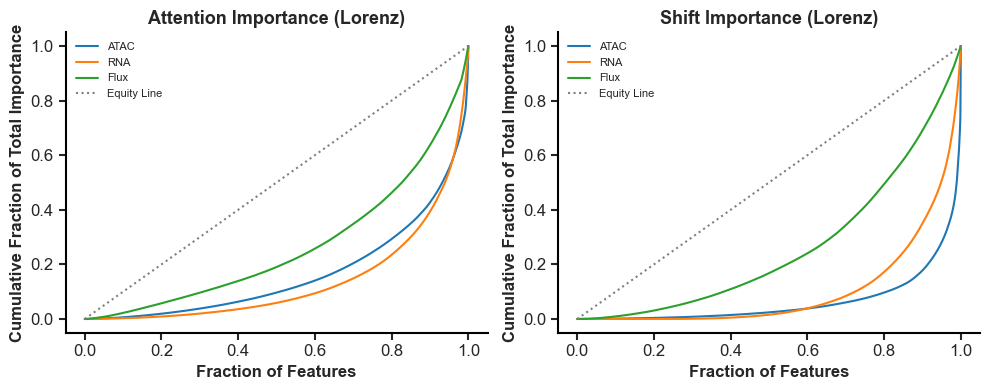

In [24]:
def plot_modality_importance_pareto(df_features, importance_cols=("importance_att", "importance_shift"),
                                    modality_col="modality", title1="Attention Importance (Lorenz)", title2="Shift Importance (Lorenz)"):
    """
    Plot Lorenz-like (Pareto) curves for feature importance values split by modality.
    Uses df_features only.
    """
    skip_features = {'batch_rna', 'batch_atac', 'batch_flux'}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    modalities = [m for m in df_features[modality_col].unique() if pd.notnull(m)]

    def compute_curve(scores):
        norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
        sorted_scores = np.sort(norm_scores)
        cum_scores = np.cumsum(sorted_scores)
        total = cum_scores[-1]
        frac = cum_scores / total if total != 0 else cum_scores
        x = np.insert(np.arange(1, len(sorted_scores)+1) / len(sorted_scores), 0, 0)
        frac = np.insert(frac, 0, 0)
        return x, frac

    for modality in modalities:
        sub = df_features[(df_features[modality_col] == modality) & (~df_features["feature"].isin(skip_features))]
        scores = sub[importance_cols[0]].values
        if len(scores) == 0:
            continue
        x, frac = compute_curve(scores)
        ax1.plot(x, frac, label=str(modality))
    ax1.plot([0, 1], [0, 1], ls=":", color="gray", label="Equity Line")
    ax1.set_xlabel("Fraction of Features", fontsize=12)
    ax1.set_ylabel("Cumulative Fraction of Total Importance", fontsize=12)
    ax1.set_title(title1, fontsize=13)
    ax1.legend(fontsize=8)

    for modality in modalities:
        sub = df_features[(df_features[modality_col] == modality) & (~df_features["feature"].isin(skip_features))]
        scores = sub[importance_cols[1]].values
        if len(scores) == 0:
            continue
        x, frac = compute_curve(scores)
        ax2.plot(x, frac, label=str(modality))
    ax2.plot([0, 1], [0, 1], ls=":", color="gray", label="Equity Line")
    ax2.set_xlabel("Fraction of Features", fontsize=12)
    ax2.set_ylabel("Cumulative Fraction of Total Importance", fontsize=12)
    ax2.set_title(title2, fontsize=13)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    return fig

fig = plot_modality_importance_pareto(df_features)
plt.show()


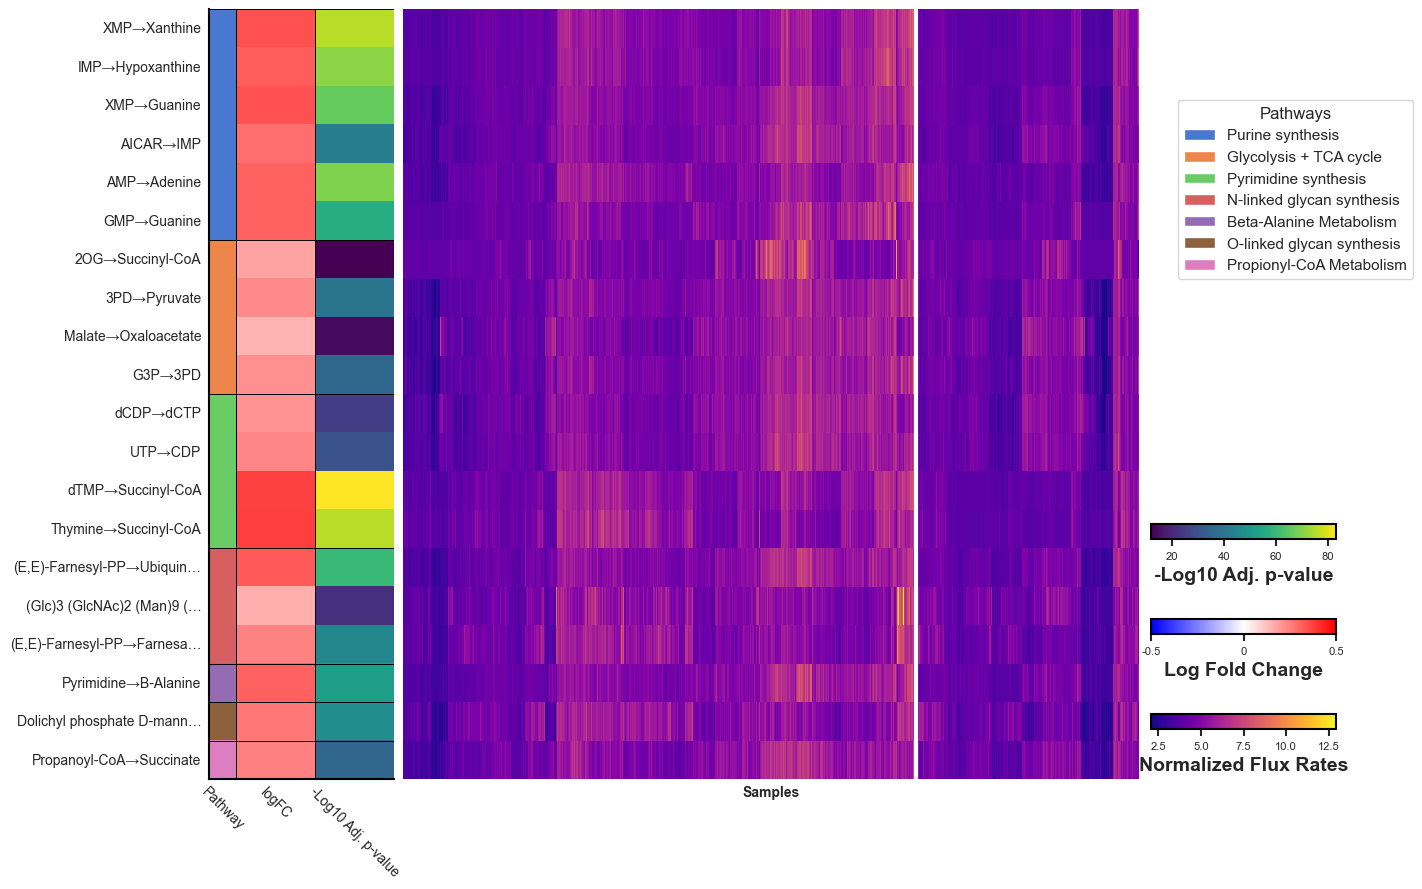

In [25]:
def plot_flux_heatmap(df_features, top_n=30, metric='mean_rank'):
    flux_combined_df = df_features[df_features.modality == "Flux"]

    top30_df = flux_combined_df.sort_values(metric).head(top_n).copy()
    top30_df = top30_df[~top30_df['feature'].str.contains('batch_flux')]

    pathway_counts = top30_df['pathway'].value_counts()
    top30_df['pathway_count'] = top30_df['pathway'].map(pathway_counts)
    top30_df.sort_values(['pathway_count', 'pathway'], ascending=[False, True], inplace=True)
    features_order = top30_df['feature'].tolist()

    heatmap_data = adata_Flux_labelled[features_order].T  # rows: reactions, cols: samples

    rp_samples = flux_labels[flux_labels == 'reprogramming'].index.tolist()
    de_samples = flux_labels[flux_labels == 'dead-end'].index.tolist()

    if len(rp_samples) > 1:
        rp_data = heatmap_data[rp_samples]
        Z_rp = linkage(rp_data.T, method='average', metric='euclidean')
        ordered_idx_rp = leaves_list(Z_rp)
        ordered_rp = list(reversed(rp_data.columns[ordered_idx_rp]))
    else:
        ordered_rp = rp_samples

    if len(de_samples) > 1:
        de_data = heatmap_data[de_samples]
        Z_de = linkage(de_data.T, method='average', metric='euclidean')
        ordered_idx_de = leaves_list(Z_de)
        ordered_de = list(de_data.columns[ordered_idx_de])
    else:
        ordered_de = de_samples

    ordered_samples = ordered_rp + ordered_de
    heatmap_data = heatmap_data[ordered_samples]
    flux_labels_ordered = flux_labels.loc[ordered_samples].str.capitalize()  # Capitalize group names

    group_palette = sns.color_palette("Set1", 2)
    sample_color_dict = {'Reprogramming': group_palette[0], 'Dead-end': group_palette[1]}

    unique_pathways = top30_df['pathway'].unique()
    pathway_palette = sns.color_palette("muted", len(unique_pathways))
    pathway_color_dict = dict(zip(unique_pathways, pathway_palette))
    reaction_pathway_series = top30_df.set_index('feature').loc[features_order, 'pathway']
    reaction_pathway_colors = reaction_pathway_series.map(pathway_color_dict)

    log_fc_values = top30_df.set_index('feature').loc[features_order, 'log_fc']
    
    norm_logfc = mcolors.Normalize(vmin=-0.5, vmax=0.5)
    reaction_logfc_colors = log_fc_values.apply(lambda x: plt.cm.bwr(norm_logfc(x)))

    pval_series = top30_df.set_index('feature').loc[features_order, 'pval_adj_log']
    norm_pval = mcolors.Normalize(vmin=pval_series.min(), vmax=pval_series.max())
    reaction_pval_colors = pval_series.apply(lambda x: plt.cm.viridis(norm_pval(x)))

    max_length = 25
    def truncate_feature_name(name, max_length=15):
        return name if len(name) <= max_length else name[:max_length] + "…"
    truncated_features = [truncate_feature_name(feat, max_length) for feat in features_order]

    pathway_legend_handles = [Patch(facecolor=pathway_color_dict[p], label=p) for p in pathway_color_dict]
    group_legend_handles   = [Patch(facecolor=sample_color_dict[label], label=label) for label in sample_color_dict]

    fig = plt.figure(figsize=(12, 10))
    gs = gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[0.25, 1], wspace=0.02)

    ax_left = fig.add_subplot(gs[0, 0])
    n_reactions = len(features_order)
    w_pathway = 1/3    # for pathway annotation
    w_logfc   = 1      # logFC annotation width
    w_pval    = 1      # -Log10 Adj. p-value annotation width
    total_width = w_pathway + w_logfc + w_pval

    extent_pathway = [0, w_pathway, n_reactions, 0]
    extent_logfc   = [w_pathway, w_pathway + w_logfc, n_reactions, 0]
    extent_pval    = [w_pathway + w_logfc, total_width, n_reactions, 0]

    ax_left.imshow(
        np.array([mcolors.to_rgba(reaction_pathway_colors[feat]) for feat in features_order])
        .reshape(n_reactions, 1, 4),
        aspect='auto', interpolation='none', origin='upper', extent=extent_pathway
    )
    ax_left.imshow(
        np.array([reaction_logfc_colors[feat] for feat in features_order])
        .reshape(n_reactions, 1, 4),
        aspect='auto', interpolation='none', origin='upper', extent=extent_logfc
    )
    ax_left.imshow(
        np.array([reaction_pval_colors[feat] for feat in features_order])
        .reshape(n_reactions, 1, 4),
        aspect='auto', interpolation='none', origin='upper', extent=extent_pval
    )

    xticks = [w_pathway/2, w_pathway + w_logfc/2, w_pathway + w_logfc + w_pval/2]
    ax_left.set_xticks(xticks)
    ax_left.set_xticklabels(["Pathway", "logFC", "-Log10 Adj. p-value"], fontsize=10, rotation=-45)
    ax_left.tick_params(axis='x', length=0)

    ax_left.set_yticks([])  # remove default ticks

    for i, label in enumerate(truncated_features):
        y_pos = i + 0.5
        ax_left.text(-0.1, y_pos, label, ha='right', va='center', fontsize=10, transform=ax_left.transData)

    rect_pathway = plt.Rectangle((0, 0), w_pathway, n_reactions,
                                linewidth=0.7, edgecolor='black', facecolor='none',
                                transform=ax_left.transData)
    rect_logfc = plt.Rectangle((w_pathway, 0), w_logfc, n_reactions,
                            linewidth=0.7, edgecolor='black', facecolor='none',
                            transform=ax_left.transData)
    rect_pval = plt.Rectangle((w_pathway + w_logfc, 0), w_pval, n_reactions,
                            linewidth=0.7, edgecolor='black', facecolor='none',
                            transform=ax_left.transData)
    ax_left.add_patch(rect_pathway)
    ax_left.add_patch(rect_logfc)
    ax_left.add_patch(rect_pval)

    for i in range(n_reactions - 1):
        if reaction_pathway_series.iloc[i] != reaction_pathway_series.iloc[i+1]:
            y_line = i + 1
            ax_left.hlines(y_line, 0, total_width, colors='black', linewidth=0.7)

    ax_heatmap = fig.add_subplot(gs[0, 1])
    sns.heatmap(heatmap_data, ax=ax_heatmap, cmap="plasma", cbar=False,
                xticklabels=False, yticklabels=False)
    ax_heatmap.set_ylabel("")
    ax_heatmap.set_xlabel("Samples", fontsize=10)

    split_index = len(ordered_rp)
    ax_heatmap.axvline(x=split_index+4, color='white', lw=3)

    if ax_heatmap.collections:
        ax_heatmap.collections[0].set_rasterized(True)
    heatmap_pos = ax_heatmap.get_position()

    cbar_width       = heatmap_pos.height / 5  # Height for each colorbar.
    cbar_padding     = 0.04  # This can be kept or adjusted as needed.
    vertical_spacing = 0.08  # Adjust this value to control vertical gaps.
    cbar_height      = 0.015
    base_x           = heatmap_pos.x1 + cbar_padding - 0.03
    bottom_y       = heatmap_pos.y0 + 0.05

    hm_vmin, hm_vmax = heatmap_data.min().min(), heatmap_data.max().max()
    sm_hm = plt.cm.ScalarMappable(cmap="plasma", norm=mcolors.Normalize(vmin=hm_vmin, vmax=hm_vmax))
    sm_hm.set_array([])
    ax_cbar_hm = fig.add_axes([base_x, bottom_y, cbar_width, cbar_height])
    cbar_hm = fig.colorbar(sm_hm, cax=ax_cbar_hm, orientation="horizontal")
    cbar_hm.ax.tick_params(labelsize=8)
    cbar_hm.set_label("Normalized Flux Rates")

    sm_logfc = plt.cm.ScalarMappable(cmap="bwr", norm=norm_logfc)
    sm_logfc.set_array([])
    ax_cbar_logfc = fig.add_axes([base_x, bottom_y + cbar_height + vertical_spacing, cbar_width, cbar_height])
    cbar_logfc = fig.colorbar(sm_logfc, cax=ax_cbar_logfc, orientation="horizontal")
    cbar_logfc.ax.tick_params(labelsize=8)
    cbar_logfc.set_label("Log Fold Change")
    cbar_logfc.set_ticks([-0.5, 0, 0.5])
    cbar_logfc.set_ticklabels(["-0.5", "0", "0.5"])

    sm_pval = plt.cm.ScalarMappable(cmap="viridis", norm=norm_pval)
    sm_pval.set_array([])
    ax_cbar_pval = fig.add_axes([base_x, bottom_y + 2 * (cbar_height + vertical_spacing), cbar_width, cbar_height])
    cbar_pval = fig.colorbar(sm_pval, cax=ax_cbar_pval, orientation="horizontal")
    cbar_pval.ax.tick_params(labelsize=8)
    cbar_pval.set_label("-Log10 Adj. p-value")

    ax_leg1 = fig.add_axes([0.99, 0.55, 0.08, 0.3])
    ax_leg1.axis('off')
    leg1 = ax_leg1.legend(handles=pathway_legend_handles, title="Pathways",
                        loc='center', frameon=True, fontsize=11, title_fontsize=12)
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    return fig

fig = plot_flux_heatmap(df_features, top_n=20, metric='mean_rank')
plt.show()


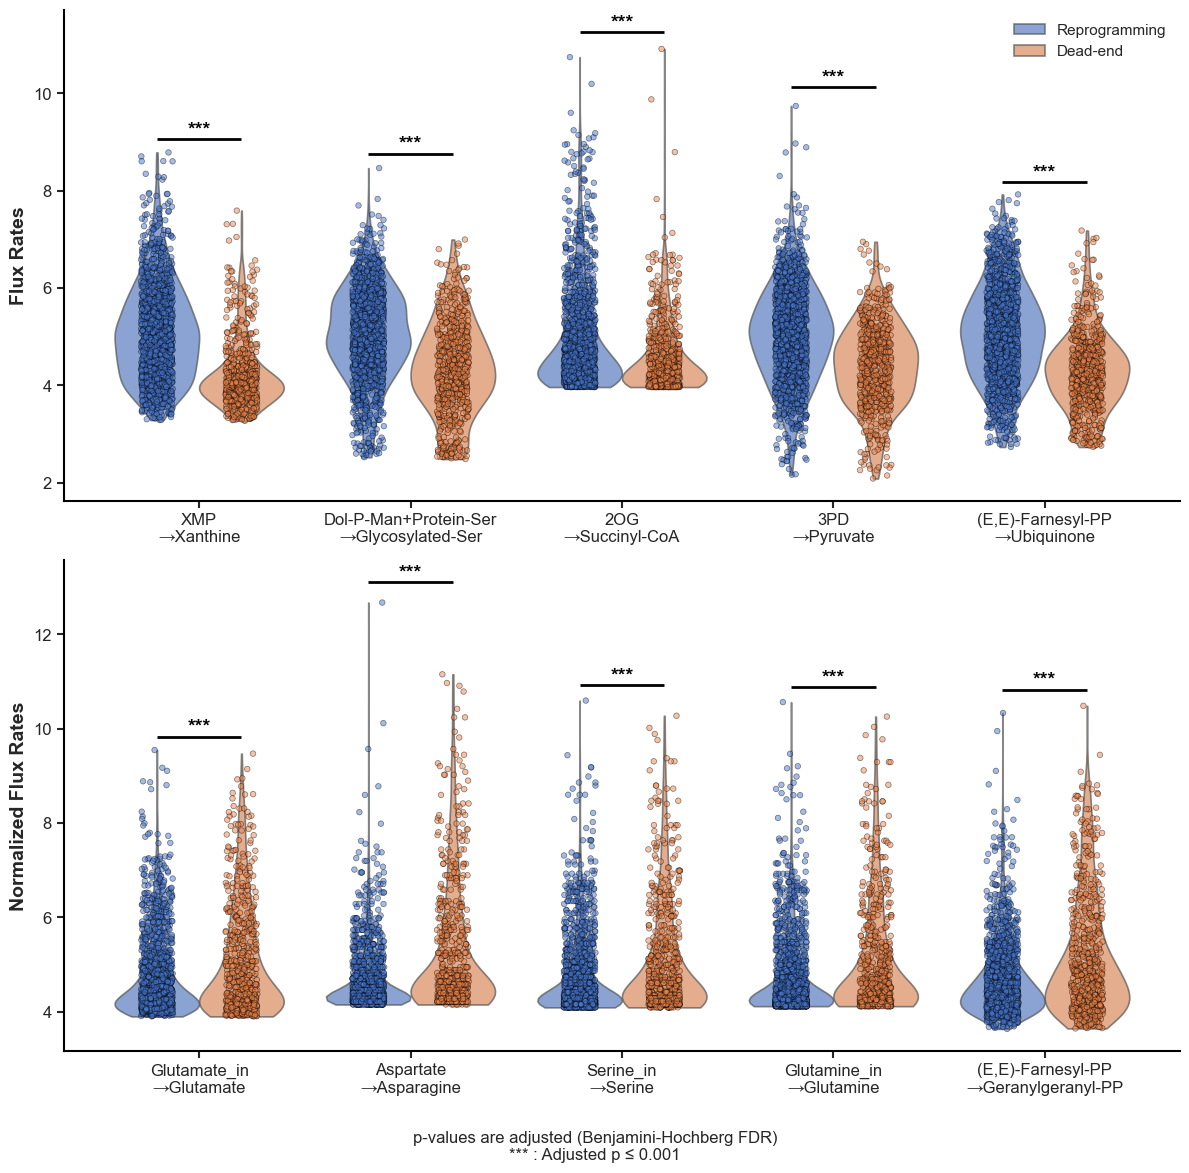

In [26]:
def plot_top_fate_specific_reactions(df = df_features):
      
    flux_features = df[df.modality=='Flux']
    top_flux_markers_re = flux_features[flux_features.group=='reprogramming'].sort_values(by='mean_rank', ascending=True).head(5)
    top_flux_markers_de = flux_features[flux_features.group=='dead-end'].sort_values(by='mean_rank', ascending=True).head(5)

    def trim_feature(name):
        if name == "Dolichyl phosphate D-mannose+Protein serine→(Gal)1 (GlcNAc)1 (Man)1 (Ser/Thr)1":
            name = "Dol-P-Man+Protein-Ser→Glycosylated-Ser"
        if 'glutamate' in name:
            name = name.replace('glutamate', 'Glutamate')
        if 'serine' in name:
            name = name.replace('serine', 'Serine')

        return name if len(name) <= 50 else name[:47] + "..."

    def split_feature_label(name):
        return name.replace("→", "\n→")

    def significance_stars(p):
        """Converts p-values into significance stars."""
        if p <= 0.001:
            return '***'
        elif p <= 0.01:
            return '**'
        elif p <= 0.05:
            return '*'
        else:
            return ''

    top_features_re = top_flux_markers_re["feature"].tolist()
    top_features_de = top_flux_markers_de["feature"].tolist()

    order_re = [trim_feature(f) for f in top_features_re]
    order_de = [trim_feature(f) for f in top_features_de]

    signif_re = {trim_feature(row['feature']): significance_stars(row['pval_adj'])
                for _, row in top_flux_markers_re.sort_values(by="mean_rank").head(5).iterrows()}
    signif_de = {trim_feature(row['feature']): significance_stars(row['pval_adj'])
                for _, row in top_flux_markers_de.sort_values(by="mean_rank").head(5).iterrows()}

    df_re = adata_Flux_labelled[top_features_re].copy()
    df_re["group"] = flux_labels.map(lambda x: x.capitalize())
    df_re_long = df_re.reset_index().melt(id_vars=["index", "group"], var_name="Feature", value_name="Value")
    df_re_long["Feature"] = df_re_long["Feature"].apply(trim_feature)

    df_de = adata_Flux_labelled[top_features_de].copy()
    df_de["group"] = flux_labels.map(lambda x: x.capitalize())
    df_de_long = df_de.reset_index().melt(id_vars=["index", "group"], var_name="Feature", value_name="Value")
    df_de_long["Feature"] = df_de_long["Feature"].apply(trim_feature)

    fig, axes = plt.subplots(2, 1, sharey=False, figsize=(12, 12))

    palette = "muted"

    sns.violinplot(x="Feature", y="Value", hue="group", data=df_re_long, palette=palette, ax=axes[0], order=order_re,
                cut=0, scale="width", inner=None, linewidth=1.2, alpha=0.7)

    sns.stripplot(x="Feature", y="Value", hue="group", data=df_re_long, palette=palette, ax=axes[0], order=order_re,
                dodge=True, jitter=0.15, alpha=0.5, edgecolor="black", linewidth=0.5, size=4, rasterized=True)

    axes[0].set_ylabel("Flux Rates")
    axes[0].set_xlabel("")

    axes[0].set_xticklabels([split_feature_label(label.get_text()) for label in axes[0].get_xticklabels()], fontsize=12)

    for strip in axes[0].collections:
        strip.set_zorder(3)

    sns.violinplot(x="Feature", y="Value", hue="group", data=df_de_long, palette=palette, ax=axes[1], order=order_de,
                cut=0, scale="width", inner=None, linewidth=1.2, alpha=0.7)

    sns.stripplot(x="Feature", y="Value", hue="group", data=df_de_long, palette=palette, ax=axes[1], order=order_de,
                dodge=True, jitter=0.15, alpha=0.5, edgecolor="black", linewidth=0.5, size=4, rasterized=True)

    axes[1].set_ylabel("Normalized Flux Rates")
    axes[1].set_xlabel("")

    axes[1].set_xticklabels([split_feature_label(label.get_text()) for label in axes[1].get_xticklabels()], fontsize=12)

    for strip in axes[1].collections:
        strip.set_zorder(3)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles[:2], labels[:2])
    axes[1].legend().set_visible(False)

    for i, feat in enumerate(order_re):
        d = df_re_long[df_re_long["Feature"] == feat]["Value"]
        max_val = d.max()
        offset = (d.max() - d.min()) * 0.05 if (d.max() - d.min()) != 0 else 0.1
        star = signif_re.get(feat, '')

        if star:
            axes[0].hlines(y=max_val + offset, xmin=i - 0.2, xmax=i + 0.2, color="black", linewidth=2)
            axes[0].text(i, max_val + offset, star, ha="center", va="bottom", color="black", fontsize=14, fontweight="bold")

    for i, feat in enumerate(order_de):
        d = df_de_long[df_de_long["Feature"] == feat]["Value"]
        max_val = d.max()
        offset = (d.max() - d.min()) * 0.05 if (d.max() - d.min()) != 0 else 0.1
        star = signif_de.get(feat, '')

        if star:
            axes[1].hlines(y=max_val + offset, xmin=i - 0.2, xmax=i + 0.2, color="black", linewidth=2)
            axes[1].text(i, max_val + offset, star, ha="center", va="bottom", color="black", fontsize=14, fontweight="bold")

    fig.text(0.5, 0.02, "p-values are adjusted (Benjamini-Hochberg FDR)\n*** : Adjusted p ≤ 0.001", ha="center", va="center", fontsize=12)

    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    return fig


fig = plot_top_fate_specific_reactions()
plt.show()


In [27]:
df_features[(df_features.modality=='Flux')].sort_values(by='mean_rank', ascending=True).head(10)

,mean_rank,feature,rank_shift,rank_att,rank_shift_in_modal,rank_att_in_modal,modality,importance_shift,importance_att,top_10_pct,...,std_de,std_re,pval,pval_adj,log_fc,group,pval_adj_log,mean_diff,pathway,module
1981,55.5,XMP→Xanthine,40,71,3,2,Flux,0.070881,0.001868,both,...,0.614697,0.854767,4.913970e-78,0.0,0.342436,reprogramming,75.713008,0.748136,Purine synthesis,M_145
1885,69.0,Dolichyl phosphate D-mannose+Protein serine→(G...,53,85,6,3,Flux,0.056596,0.001658,both,...,0.820929,0.817798,2.116897e-48,0.0,0.268822,reprogramming,46.896149,0.596168,O-linked glycan synthesis,M_125
1845,72.5,2OG→Succinyl-CoA,48,97,4,4,Flux,0.061477,0.001523,both,...,0.999223,1.380158,5.583689e-13,0.0,0.180825,reprogramming,12.170784,0.449075,Glycolysis + TCA cycle,M_9
1846,126.5,3PD→Pyruvate,68,185,12,6,Flux,0.048831,0.000957,both,...,0.728725,0.838821,1.488236e-40,0.0,0.227753,reprogramming,39.536517,0.533394,Glycolysis + TCA cycle,M_4
1833,128.0,"(E,E)-Farnesyl-PP→Ubiquinone",77,179,17,5,Flux,0.044255,0.000983,both,...,0.779253,0.951598,4.082193e-62,0.0,0.321702,reprogramming,60.242978,0.753711,N-linked glycan synthesis,M_116
1840,137.5,(Glc)3 (GlcNAc)2 (Man)9 (PP-Dol)1+Protein aspa...,86,189,21,7,Flux,0.039036,0.000945,both,...,0.615270,0.785550,1.520189e-22,0.0,0.157720,reprogramming,21.671179,0.353717,N-linked glycan synthesis,M_120
1987,138.5,dCDP→dCTP,80,197,19,9,Flux,0.041265,0.000907,both,...,0.953575,1.044138,6.144087e-26,0.0,0.208046,reprogramming,25.027626,0.526818,Pyrimidine synthesis,M_161
1921,138.5,IMP→Hypoxanthine,75,202,15,10,Flux,0.044716,0.000897,shift,...,0.574026,0.823145,6.004070e-73,0.0,0.318511,reprogramming,70.899335,0.690068,Purine synthesis,M_143
1931,141.0,Malate→Oxaloacetate,74,208,14,11,Flux,0.044992,0.000866,shift,...,0.962719,0.951607,3.960863e-15,0.0,0.146091,reprogramming,14.300753,0.366592,Glycolysis + TCA cycle,M_13
1980,142.5,XMP→Guanine,50,235,5,14,Flux,0.060469,0.000788,shift,...,0.750582,0.948002,2.233535e-68,0.0,0.337266,reprogramming,66.425698,0.785923,Purine synthesis,M_148


In [28]:
df_features[(df_features.modality=='Flux')].sort_values(by='mean_rank', ascending=True).head(20)

,mean_rank,feature,rank_shift,rank_att,rank_shift_in_modal,rank_att_in_modal,modality,importance_shift,importance_att,top_10_pct,...,std_de,std_re,pval,pval_adj,log_fc,group,pval_adj_log,mean_diff,pathway,module
1981,55.5,XMP→Xanthine,40,71,3,2,Flux,0.070881,0.001868,both,...,0.614697,0.854767,4.913970e-78,0.0,0.342436,reprogramming,75.713008,0.748136,Purine synthesis,M_145
1885,69.0,Dolichyl phosphate D-mannose+Protein serine→(G...,53,85,6,3,Flux,0.056596,0.001658,both,...,0.820929,0.817798,2.116897e-48,0.0,0.268822,reprogramming,46.896149,0.596168,O-linked glycan synthesis,M_125
1845,72.5,2OG→Succinyl-CoA,48,97,4,4,Flux,0.061477,0.001523,both,...,0.999223,1.380158,5.583689e-13,0.0,0.180825,reprogramming,12.170784,0.449075,Glycolysis + TCA cycle,M_9
1846,126.5,3PD→Pyruvate,68,185,12,6,Flux,0.048831,0.000957,both,...,0.728725,0.838821,1.488236e-40,0.0,0.227753,reprogramming,39.536517,0.533394,Glycolysis + TCA cycle,M_4
1833,128.0,"(E,E)-Farnesyl-PP→Ubiquinone",77,179,17,5,Flux,0.044255,0.000983,both,...,0.779253,0.951598,4.082193e-62,0.0,0.321702,reprogramming,60.242978,0.753711,N-linked glycan synthesis,M_116
1840,137.5,(Glc)3 (GlcNAc)2 (Man)9 (PP-Dol)1+Protein aspa...,86,189,21,7,Flux,0.039036,0.000945,both,...,0.615270,0.785550,1.520189e-22,0.0,0.157720,reprogramming,21.671179,0.353717,N-linked glycan synthesis,M_120
1987,138.5,dCDP→dCTP,80,197,19,9,Flux,0.041265,0.000907,both,...,0.953575,1.044138,6.144087e-26,0.0,0.208046,reprogramming,25.027626,0.526818,Pyrimidine synthesis,M_161
1921,138.5,IMP→Hypoxanthine,75,202,15,10,Flux,0.044716,0.000897,shift,...,0.574026,0.823145,6.004070e-73,0.0,0.318511,reprogramming,70.899335,0.690068,Purine synthesis,M_143
1931,141.0,Malate→Oxaloacetate,74,208,14,11,Flux,0.044992,0.000866,shift,...,0.962719,0.951607,3.960863e-15,0.0,0.146091,reprogramming,14.300753,0.366592,Glycolysis + TCA cycle,M_13
1980,142.5,XMP→Guanine,50,235,5,14,Flux,0.060469,0.000788,shift,...,0.750582,0.948002,2.233535e-68,0.0,0.337266,reprogramming,66.425698,0.785923,Purine synthesis,M_148


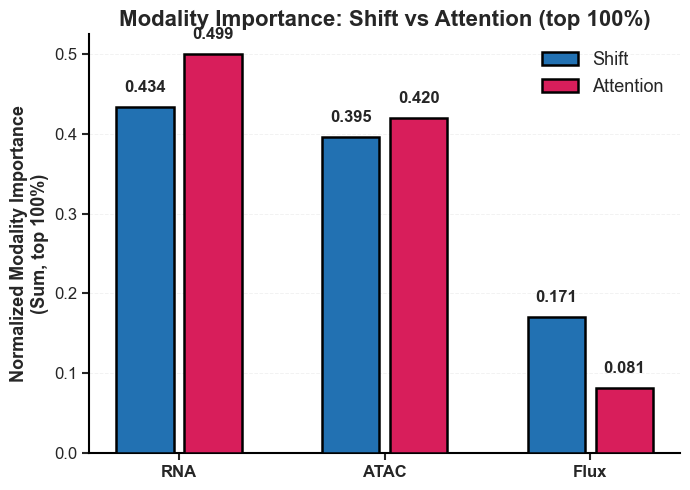

In [29]:
def plot_modality_importance_combined(df_features, agg_method='sum', top_type='pct', top_value=100):
    modality_order = ['RNA', 'ATAC', 'Flux']
    modality_stats_list = []
    top_desc = ''
    
    for modality in modality_order:
        modality_df = df_features[df_features['modality'] == modality].copy()
        n_total = len(modality_df)
        if top_type == 'pct':
            n_features_shift = n_features_att = max(1, int(n_total * top_value / 100))
            top_desc = f"top {top_value}%"
        elif top_type == 'n':
            n_features_shift = n_features_att = min(top_value, n_total)
            top_desc = f"top {top_value}"
        else:
            raise ValueError("top_type must be 'pct' or 'n'")

        top_shift_df = modality_df.nlargest(n_features_shift, 'importance_shift')
        top_att_df = modality_df.nlargest(n_features_att, 'importance_att')

        if agg_method == 'sum':
            shift_value = top_shift_df['importance_shift'].sum()
            att_value = top_att_df['importance_att'].sum()
        elif agg_method == 'mean':
            shift_value = top_shift_df['importance_shift'].mean()
            att_value = top_att_df['importance_att'].mean()
        elif agg_method == 'median':
            shift_value = top_shift_df['importance_shift'].median()
            att_value = top_att_df['importance_att'].median()
        else:
            raise ValueError("agg_method must be 'sum', 'mean', or 'median'")

        modality_stats_list.append({
            'modality': modality,
            'importance_shift': shift_value,
            'importance_att': att_value
        })

    modality_stats = pd.DataFrame(modality_stats_list)
    shift_total = modality_stats['importance_shift'].sum()
    att_total = modality_stats['importance_att'].sum()
    if shift_total > 0:
        modality_stats['importance_shift'] /= shift_total
    if att_total > 0:
        modality_stats['importance_att'] /= att_total

    method_colors = {'Shift': '#2271B2', 'Attention': '#D81E5B'}
    methods = ['Shift', 'Attention']
    bar_colors = [method_colors['Shift'], method_colors['Attention']]

    x = np.arange(len(modality_stats))
    width = 0.28
    gap = 0.05

    fig, ax = plt.subplots(figsize=(7, 5))

    bars1 = ax.bar(x - width/2 - gap/2, modality_stats['importance_shift'], width=width, 
                   color=bar_colors[0], edgecolor='black', linewidth=1.8, label='Shift', zorder=3)
    bars2 = ax.bar(x + width/2 + gap/2, modality_stats['importance_att'], width=width, 
                   color=bar_colors[1], edgecolor='black', linewidth=1.8, label='Attention', zorder=3)

    ax.set_ylabel(f'Normalized Modality Importance\n({agg_method.capitalize()}, {top_desc})', fontsize=13, fontweight='bold')
    ax.set_title(f'Modality Importance: Shift vs Attention ({top_desc})', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modality_stats['modality'], fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.25, zorder=0)

    for bar, value in zip(bars1, modality_stats['importance_shift']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    for bar, value in zip(bars2, modality_stats['importance_att']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend(fontsize=13, frameon=False, loc='upper right')
    plt.tight_layout()
    return fig

fig = plot_modality_importance_combined(df_features, agg_method='sum', top_type='pct', top_value=100)

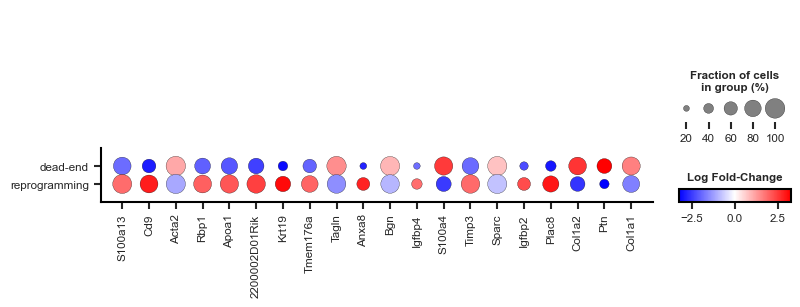

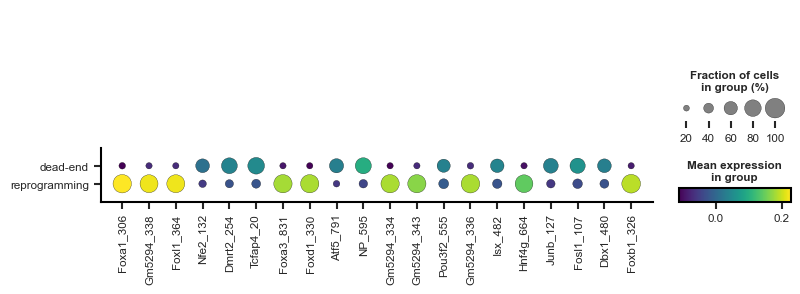

In [30]:
def plot_dotplots_by_group(
    df_features,
    adata,
    modality="RNA",
    groupby="label",
    top_n=15,
    metric="mean_rank",
    no_group = True,
):
    df_mod = df_features[df_features["modality"] == modality]
    top_re = (
        df_mod[df_mod["group"].str.lower() == "reprogramming"]
        .sort_values(by=metric)
        .head(top_n)["feature"]
        .tolist()
    )
    top_de = (
        df_mod[df_mod["group"].str.lower() == "dead-end"]
        .sort_values(by=metric)
        .head(top_n)["feature"]
        .tolist()
    )
    if no_group:
        marker_dict = df_mod.sort_values(by=metric).head(top_n)["feature"].tolist()
    else:
        marker_dict = {"reprogramming": top_re, "dead-end": top_de}

    scaled = adata.copy()
    if modality.upper() == "RNA":
        sc.pp.normalize_total(scaled, target_sum=1e4)
        sc.pp.log1p(scaled)
        sc.tl.rank_genes_groups(scaled, groupby='label', method='wilcoxon', use_raw=False)
        dotplot = sc.pl.rank_genes_groups_dotplot(
            scaled,
            groupby=groupby,
            values_to_plot="logfoldchanges",
            var_names=marker_dict,
            cmap="bwr",
            colorbar_title="Log Fold-Change",
            show=False,
            use_raw=False,
            var_group_rotation=0,
            dendrogram=False,
            return_fig=True,
        )
    else:
        dotplot = sc.pl.dotplot(scaled, 
                marker_dict, 
                groupby='label', 
                cmap='viridis', 
                show=False, 
                use_raw=False, 
                var_group_rotation=0,
                return_fig=True)
    return dotplot

fig1 = plot_dotplots_by_group(
        df_features,
        adata_RNA_labelled,
        modality="RNA",
        groupby="label",
        top_n=20,
    )

fig2 = plot_dotplots_by_group(
        df_features,
        adata_ATAC_labelled,
        modality="ATAC",
        groupby="label",
        top_n=20,
    )
fig1.show()
fig2.show()

<Figure size 640x480 with 0 Axes>

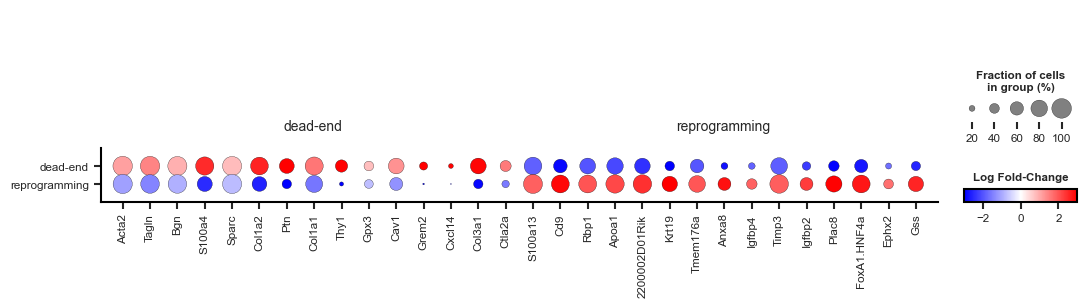

In [31]:
top_rna_markers_de = df_features[df_features['modality'] == 'RNA'][df_features['group'] == 'dead-end']
top_rna_markers_re = df_features[df_features['modality'] == 'RNA'][df_features['group'] == 'reprogramming']

de_top = top_rna_markers_de.sort_values(by='mean_rank').head(15)['feature'].tolist()
re_top = top_rna_markers_re.sort_values(by='mean_rank').head(15)['feature'].tolist()
marker_genes_dict = {
    "dead-end": de_top,
    "reprogramming": re_top
}

scaled_rna = adata_RNA_labelled.copy()
sc.pp.normalize_total(scaled_rna, target_sum=1e4)
sc.pp.log1p(scaled_rna)

sc.tl.rank_genes_groups(scaled_rna, groupby='label', method='wilcoxon', use_raw=False)

plt.figure()  # Create a new figure
sc.pl.rank_genes_groups_dotplot(
    scaled_rna,
    groupby='label',  
    var_names=marker_genes_dict, 
    values_to_plot='logfoldchanges',  
    cmap='bwr',  
    vmin=-3, vmax=3,
    colorbar_title='Log Fold-Change', 
    show=False,
    use_raw=False,
    var_group_rotation=0,
    dendrogram=False
)
plt.show()
plt.close() 

In [32]:
df_features[df_features.modality == "ATAC"].sort_values(by='mean_rank', ascending=True).head(10)

,mean_rank,feature,rank_shift,rank_att,rank_shift_in_modal,rank_att_in_modal,modality,importance_shift,importance_att,top_10_pct,...,std_de,std_re,pval,pval_adj,log_fc,group,pval_adj_log,mean_diff,pathway,module
1102,1.0,Foxa1_306,1,1,1,2,ATAC,1.816000,0.023609,both,...,0.204779,0.139781,2.313543e-24,0.000000,31.658024,reprogramming,21.291822,0.338856,NaN,NaN
1204,5.5,Gm5294_338,7,4,6,4,ATAC,0.173962,0.011048,both,...,0.208045,0.192040,4.096515e-19,0.000000,2.993346,reprogramming,17.165901,0.289132,NaN,NaN
1137,6.0,Foxl1_364,9,3,7,3,ATAC,0.166957,0.014082,both,...,0.208045,0.192040,4.096515e-19,0.000000,2.993346,reprogramming,17.165901,0.289132,NaN,NaN
1458,6.0,Nfe2_132,3,9,3,7,ATAC,0.245260,0.007149,both,...,0.105776,0.092487,3.413335e-06,0.000013,-1.104146,dead-end,4.884190,-0.067140,NaN,NaN
1033,8.5,Dmrt2_254,10,7,8,6,ATAC,0.161776,0.007726,both,...,0.064851,0.068684,1.496897e-11,0.000000,-0.812362,dead-end,9.947033,-0.065280,NaN,NaN
1728,12.5,Tcfap4_20,19,6,10,5,ATAC,0.114262,0.007729,both,...,0.064780,0.053814,7.604965e-14,0.000000,-0.837195,dead-end,12.146070,-0.070648,NaN,NaN
1104,35.0,Foxa3_831,5,65,4,19,ATAC,0.226905,0.002003,both,...,0.179048,0.129700,7.341758e-22,0.000000,3.737926,reprogramming,19.568450,0.271260,NaN,NaN
1109,35.5,Foxd1_330,20,51,11,15,ATAC,0.109568,0.002525,both,...,0.174783,0.130199,7.870701e-25,0.000000,7.071175,reprogramming,21.635147,0.293782,NaN,NaN
970,36.5,Atf5_791,24,49,12,14,ATAC,0.101996,0.002592,both,...,0.120686,0.105691,8.700407e-08,0.000000,-1.397173,dead-end,6.381671,-0.089598,NaN,NaN
1430,37.5,NP_595,49,26,17,8,ATAC,0.061220,0.004686,both,...,0.149678,0.100901,1.586768e-11,0.000000,-1.570293,dead-end,9.925408,-0.140376,NaN,NaN


In [33]:
gene_count = df_features[df_features.modality == "RNA"].shape[0]
gene_count_5 = int(gene_count * 0.05) + 1

top_5_genes_reprogramming = df_features[
    (df_features.modality == "RNA") & (df_features.group == "reprogramming")
].sort_values(by='mean_rank', ascending=True).head(gene_count_5)["feature"].str.upper().tolist()

top_5_genes_dead_end = df_features[
    (df_features.modality == "RNA") & (df_features.group == "dead-end")
].sort_values(by='mean_rank', ascending=True).head(gene_count_5)["feature"].str.upper().tolist()

print(f"Top RNA genes per group: {gene_count_5}")
print("Reprogramming:", top_5_genes_reprogramming)
print("Dead-end:", top_5_genes_dead_end)

Top RNA genes per group: 48
Reprogramming: ['S100A13', 'CD9', 'RBP1', 'APOA1', '2200002D01RIK', 'KRT19', 'TMEM176A', 'ANXA8', 'IGFBP4', 'TIMP3', 'IGFBP2', 'PLAC8', 'FOXA1.HNF4A', 'EPHX2', 'GSS', 'DPEP1', 'RAMP1', 'EZR', 'KRT18', 'GSTA4', 'PIR', 'SERPINB11', 'CALML4', 'FGB', 'FAM129A', 'SPINT2', 'ACSL1', 'SLC9A3R1', 'BEX1', 'APOE', 'MSLN', 'BEX4', 'S100A16', 'STARD10', 'ATP1B1', 'MGST2', 'SORBS2', 'UPK1B', 'APOB', 'KRT8', 'ACTA1', 'DUSP1', 'KLHL13', 'IFI27L2B', 'FRMD4B', 'AIG1', 'NDNF', 'ANGPTL4']
Dead-end: ['ACTA2', 'TAGLN', 'BGN', 'S100A4', 'SPARC', 'COL1A2', 'PTN', 'COL1A1', 'THY1', 'GPX3', 'CAV1', 'GREM2', 'CXCL14', 'COL3A1', 'CTLA2A', 'CNN1', 'COL6A2', 'SPRR2K', 'VCAM1', 'PTPRZ1', 'APBB1IP', 'GNGT2', 'KIF21B', 'NCAM1', 'VCAN', 'FBLN2', 'COL12A1', 'SH3KBP1', 'CRISPLD2', 'NOV', 'FMO2', 'FBN1', 'IGFBP6', 'TMEM200A', 'CD248', 'GNG11', 'AKAP12', 'TIMP1', 'ZDBF2', 'MYL9', 'BCL11B', 'COL8A1', 'MS4A4D', 'SERPINF1', 'MYH11', 'FLRT2', 'ADM', 'TRIB3']


Reprogramming Reactome Pathways: {'Metabolism of fat-soluble vitamins', 'Post-translational protein phosphorylation', 'Plasma lipoprotein assembly', 'Regulation of IGF transport and uptake by IGFBPs', 'Visual phototransduction', 'Retinoid metabolism and transport', 'Plasma lipoprotein remodeling', 'Scavenging by Class A Receptors', 'Plasma lipoprotein assembly, remodeling, and clearance', 'Chylomicron assembly', 'Chylomicron remodeling'}
Dead-end Reactome Pathways: {'MET activates PTK2 signaling', 'Assembly of collagen fibrils and other multimeric structures', 'Collagen biosynthesis and modifying enzymes', 'Integrin cell surface interactions', 'Collagen chain trimerization', 'Signal Transduction', 'Extracellular matrix organization', 'Signaling by Receptor Tyrosine Kinases', 'Non-integrin membrane-ECM interactions', 'Platelet activation, signaling and aggregation', 'ECM proteoglycans', 'Signaling by MET', 'NCAM1 interactions', 'Degradation of the extracellular matrix', 'Collagen degrad

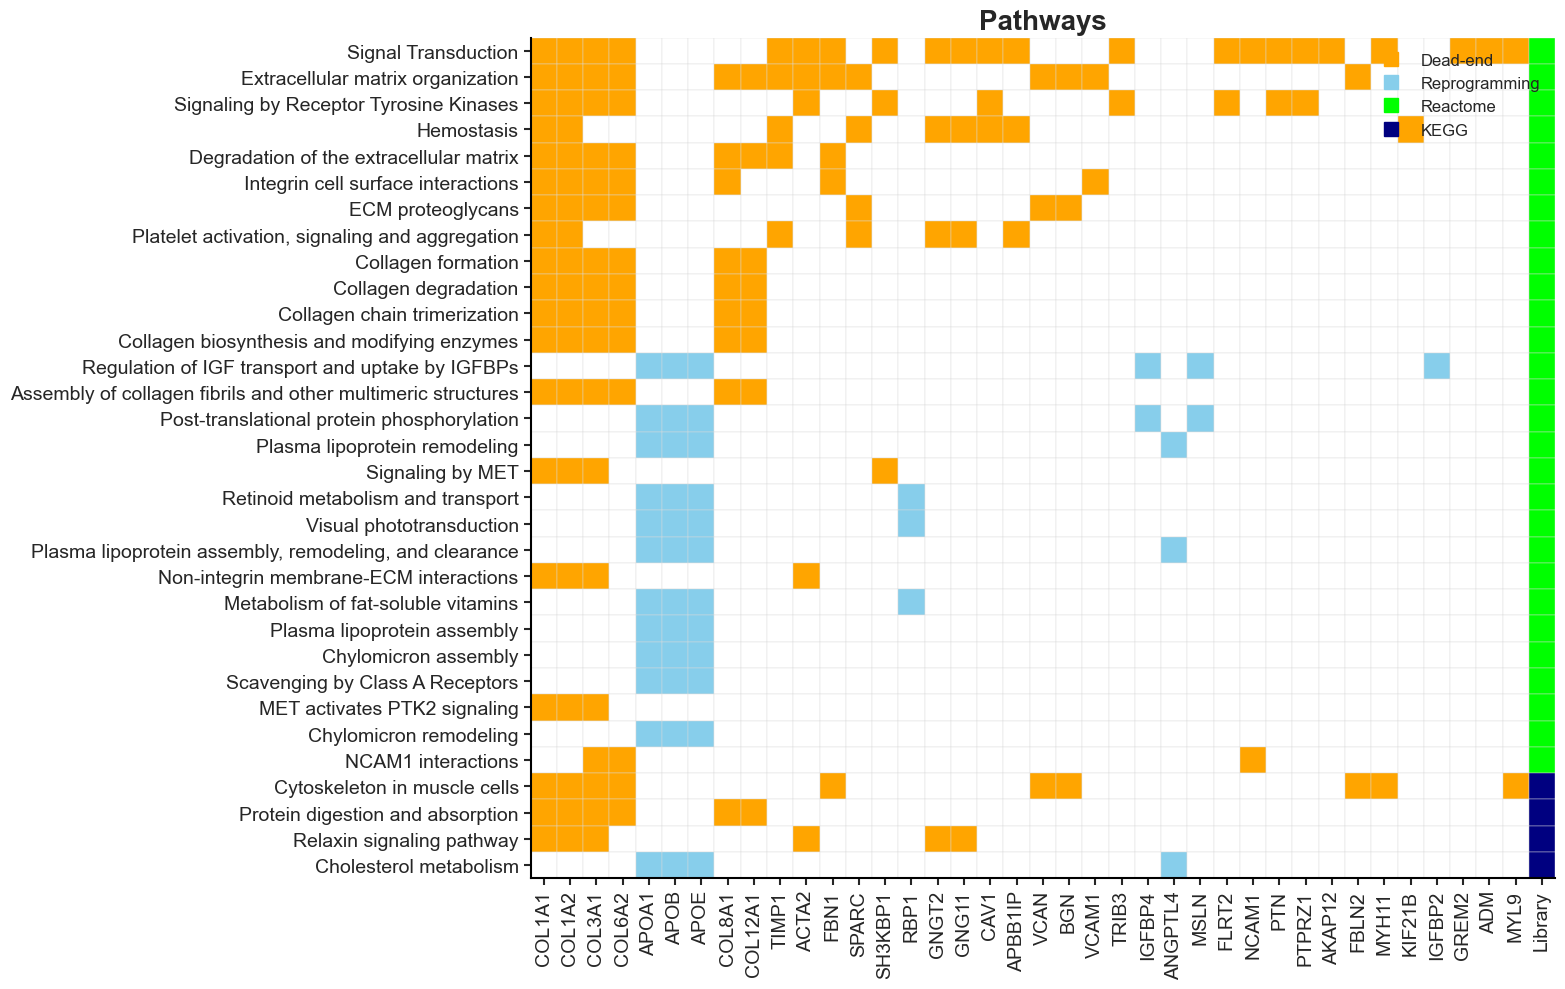

In [34]:
de_all = pd.read_csv("analysis/de_all_48.tsv", sep='\t')
re_all = pd.read_csv("analysis/re_all_48.tsv", sep='\t')
reactome_dead_end = de_all[de_all["Category"] == "REACTOME_PATHWAY"]
reactome_reprogramming = re_all[re_all["Category"] == "REACTOME_PATHWAY"]
kegg_dead_end = de_all[de_all["Category"] == "KEGG_PATHWAY"]
kegg_reprogramming = re_all[re_all["Category"] == "KEGG_PATHWAY"]

def preprocess_data_with_label(df, label):
    df = df[['Term', 'Genes', 'Benjamini']].copy()
    df['Label'] = label
    exploded = df.set_index(['Term', 'Benjamini', 'Label'])['Genes'].str.split(', ').explode().reset_index()
    return exploded

def filter_and_preprocess(df, pval_threshold, splitter, label):
    df['Term'] = df['Term'].str.split(splitter).str[-1]
    if splitter == "-":
        df['Term'] = df['Term'].str.split("~").str[-1]
    def truncate_term(x):
        if len(x) > 60:
            return x[:60] + "..."
        return x
    df['Term'] = df['Term'].apply(truncate_term)
    filtered_df = df[df['Benjamini'] < pval_threshold]
    return preprocess_data_with_label(filtered_df, label), filtered_df

pval_threshold = 0.05

reactome_dead_end_data, _ = filter_and_preprocess(reactome_dead_end, pval_threshold, "~", "Dead-end")
reactome_reprogramming_data, _ = filter_and_preprocess(reactome_reprogramming, pval_threshold, "~", "Reprogramming")
reactome_combined_data = pd.concat([reactome_dead_end_data, reactome_reprogramming_data])

kegg_dead_end_data, _ = filter_and_preprocess(kegg_dead_end, pval_threshold, ":", "Dead-end")
kegg_reprogramming_data, _ = filter_and_preprocess(kegg_reprogramming, pval_threshold, ":", "Reprogramming")
kegg_combined_data = pd.concat([kegg_dead_end_data, kegg_reprogramming_data])

print("Reprogramming Reactome Pathways:" ,set(reactome_reprogramming_data.Term.tolist()))
print("Dead-end Reactome Pathways:" ,set(reactome_dead_end_data.Term.tolist()))
print("Reprogramming KEGG Pathways:" ,set(kegg_reprogramming_data.Term.tolist()))
print("Dead-end KEGG Pathways:" ,set(kegg_dead_end_data.Term.tolist()))

def create_binary_matrix(data):
    binary_matrix = pd.crosstab(data['Term'], data['Genes'])
    label_mapping = data.groupby('Term')['Label'].first()
    pvalues = data.groupby('Term')['Benjamini'].first()
    return binary_matrix, label_mapping, pvalues

reactome_matrix, reactome_labels, reactome_pvalues = create_binary_matrix(reactome_combined_data)
kegg_matrix, kegg_labels, kegg_pvalues = create_binary_matrix(kegg_combined_data)

def sort_matrix_by_gene_and_pathway_contribution(matrix):
    sorted_pathways = matrix.sum(axis=1).sort_values(ascending=False).index
    sorted_genes = matrix.sum(axis=0).sort_values(ascending=False).index
    sorted_matrix = matrix.loc[sorted_pathways, sorted_genes]
    return sorted_matrix

reactome_matrix = sort_matrix_by_gene_and_pathway_contribution(reactome_matrix)
kegg_matrix = sort_matrix_by_gene_and_pathway_contribution(kegg_matrix)


reactome_library = pd.Series("Reactome", index=reactome_matrix.index)
kegg_library = pd.Series("KEGG", index=kegg_matrix.index)

merged_matrix = pd.concat([reactome_matrix, kegg_matrix], axis=0, sort=False).fillna(0)
merged_labels = pd.concat([reactome_labels, kegg_labels])
merged_library = pd.concat([reactome_library, kegg_library])

merged_matrix["Library"] = 0  # will be overwritten with our library code

GLOBAL_LABEL_COLORS = {"Dead-end": 1, "Reprogramming": 2}
GLOBAL_LIBRARY_COLORS = {"Reactome": 3, "KEGG": 4}

new_color_list = ["white", "orange", "#87CEEB", "lime", "navy"]


merged_matrix_colors = merged_matrix.copy()

gene_cols = merged_matrix_colors.columns.drop("Library")

for term in merged_matrix_colors.index:
    label = merged_labels.loc[term]
    label_index = GLOBAL_LABEL_COLORS[label]  # either 1 or 2
    merged_matrix_colors.loc[term, gene_cols] = merged_matrix_colors.loc[term, gene_cols] * label_index
    
    lib = merged_library.loc[term]
    merged_matrix_colors.loc[term, "Library"] = GLOBAL_LIBRARY_COLORS[lib]


def plot_merged_pathways(matrix, gene_columns, title="Pathways"):
    """
    Plot the merged pathways heatmap with an extra column showing library assignment,
    using one vector rectangle per cell for full Illustrator compatibility.
    """
    value_to_color = {
        0: "white",           # no gene
        1: "orange",          # Dead end
        2: "#87CEEB",         # Reprogramming
        3: "lime",            # Reactome
        4: "navy",            # KEGG
    }

    n_rows, n_cols = matrix.shape

    fig, ax = plt.subplots(figsize=(15, 10), facecolor="white")
    ax.set_title(title, fontsize=20)

    for row in range(n_rows):
        for col in range(n_cols):
            val = int(matrix.iat[row, col])
            color = value_to_color.get(val, "white")
            rect = Rectangle(
                (col - 0.5, row - 0.5),   # lower left corner
                1.0,                      # width
                1.0,                      # height
                facecolor=color,
                edgecolor="gainsboro",
                linewidth=0.3
            )
            ax.add_patch(rect)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -0.5)  # flip y axis so first row is at top
    ax.set_aspect("equal")

    x_labels = list(gene_columns) + ["Library"]
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(x_labels, fontsize=14, rotation=90)

    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(matrix.index, fontsize=14)

    ax.tick_params(which="both", bottom=True, left=True)

    legend_handles = []
    for label, idx in GLOBAL_LABEL_COLORS.items():
        if label in merged_labels.values:
            legend_handles.append(
                plt.Line2D([0], [0],
                           marker="s",
                           color=value_to_color[idx],
                           linestyle="None",
                           markersize=10,
                           label=label)
            )
    for lib, idx in GLOBAL_LIBRARY_COLORS.items():
        if lib in merged_library.values:
            legend_handles.append(
                plt.Line2D([0], [0],
                           marker="s",
                           color=value_to_color[idx],
                           linestyle="None",
                           markersize=10,
                           label=lib)
            )

    ax.legend(handles=legend_handles,
              fontsize=12,
              title_fontsize=14,
              loc="upper right")

    plt.tight_layout()
    plt.show()

plot_merged_pathways(merged_matrix_colors, gene_columns=gene_cols)


Found  9  significant  bp  GO terms
Found  26  significant  cc  GO terms
Found  9  significant  mf  GO terms
Reprogramming Biological Process GO Terms: ['cellular response to lipoprotein particle stimulus', 'triglyceride homeostasis', 'cholesterol homeostasis', 'lipid metabolic process', 'lipoprotein biosynthetic process']
Dead-end Biological Process GO Terms: ['cell adhesion', 'skeletal system development', 'extracellular matrix organization', 'cellular response to transforming growth factor beta stimulus']
Reprogramming Cellular Component GO Terms: ['1_extracellular space', '0_intermediate-density lipoprotein particle', '0_apical plasma membrane', '0_chylomicron', '0_low-density lipoprotein particle', '0_microvillus', '0_very-low-density lipoprotein particle', '0_cell periphery', '0_high-density lipoprotein particle', '0_sarcolemma', '1_cytoskeleton', '0_cytosol', '0_discoidal high-density lipoprotein particle']
Dead-end Cellular Component GO Terms: ['0_extracellular space', '0_extra

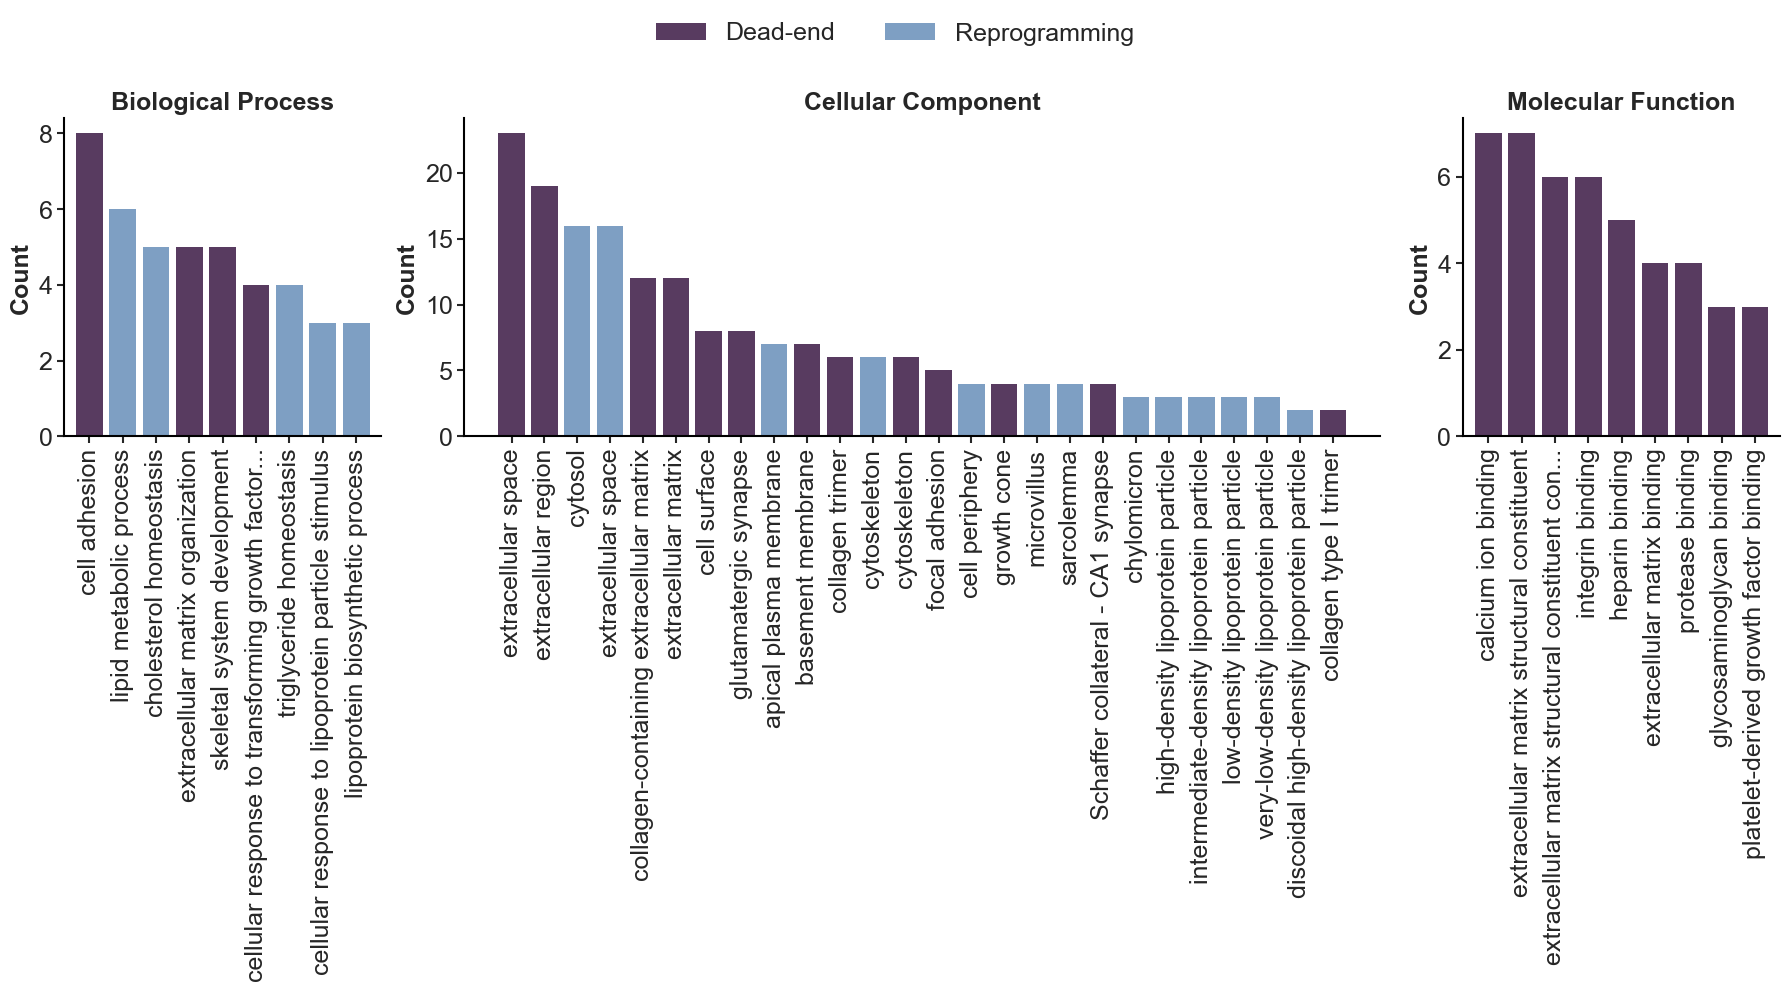

In [35]:
def trim_label(label, max_length=50):
    """Trim label to max_length. If trimmed, append '...'."""
    return label if len(label) <= max_length else label[:max_length-3] + "..."

def load_go_category(category):
    """
    Loads the dead-end and reprogramming GO files for a given category.
    category: one of 'bp', 'cc', or 'mf'
    Returns a combined DataFrame with an added column 'Group'.
    """
    pval_threshold = 0.05
    key = "GOTERM_" + category.upper() + "_DIRECT"
    df_de = de_all[de_all["Category"] == key]
    df_de = df_de[df_de["Benjamini"] < pval_threshold]
    df_de["Term"] = df_de["Term"].apply(lambda x: x.split('~')[-1])
    df_de["Group"] = "Dead-end"
    df_re = re_all[re_all["Category"] == key]
    df_re = df_re[df_re["Benjamini"] < pval_threshold]
    df_re["Term"] = df_re["Term"].apply(lambda x: x.split('~')[-1])
    df_re["Group"] = "Reprogramming"
    df = pd.concat([df_de, df_re], ignore_index=True)
    if category == "cc":
        df['Term'] = df.groupby('Term').cumcount().astype(str) + '_' + df['Term']
    print("Found ", len(df), " significant ", category, " GO terms")
    return df

df_bp = load_go_category("bp")
df_cc = load_go_category("cc")
df_mf = load_go_category("mf")

group_colors = {"Dead-end": "#5c3566ff", "Reprogramming": "#729fcfff"}

order_bp = df_bp.groupby("Term")["Count"].sum().sort_values(ascending=False).index.tolist()
order_cc = df_cc.groupby("Term")["Count"].sum().sort_values(ascending=False).index.tolist()
order_mf = df_mf.groupby("Term")["Count"].sum().sort_values(ascending=False).index.tolist()


print("Reprogramming Biological Process GO Terms:", df_bp[df_bp.Group=='Reprogramming']['Term'].tolist())
print("Dead-end Biological Process GO Terms:", df_bp[df_bp.Group=='Dead-end']['Term'].tolist())
print("Reprogramming Cellular Component GO Terms:", df_cc[df_cc.Group=='Reprogramming']['Term'].tolist())
print("Dead-end Cellular Component GO Terms:", df_cc[df_cc.Group=='Dead-end']['Term'].tolist())
print("Reprogramming Molecular Function GO Terms:", df_mf[df_mf.Group=='Reprogramming']['Term'].tolist())
print("Dead-end Molecular Function GO Terms:", df_mf[df_mf.Group=='Dead-end']['Term'].tolist())
n_bp = len(order_bp)
n_cc = len(order_cc)
n_mf = len(order_mf)

desired_bar_width = 0.5  # inches
default_bar_width = 0.8  # (data units used by seaborn.barplot)

ax_width_bp = (desired_bar_width / default_bar_width) * n_bp
ax_width_cc = (desired_bar_width / default_bar_width) * n_cc
ax_width_mf = (desired_bar_width / default_bar_width) * n_mf

wspace_inches = 1  # for example, 1 inch gap between subplots

total_axes_width = ax_width_bp + ax_width_cc + ax_width_mf

fig_width = total_axes_width + 2 * wspace_inches

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 10),
    gridspec_kw={'width_ratios': [ax_width_bp, ax_width_cc, ax_width_mf]}
)

sns.barplot(
    data=df_bp, x="Term", y="Count", hue="Group", 
    palette=group_colors, order=order_bp, ax=axes[0],
    edgecolor='none'
)
axes[0].set_title("Biological Process", fontsize=18)
axes[0].set_xlabel("", fontsize=18)
axes[0].set_ylabel("Count", fontsize=18)
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_xticklabels([trim_label(label) for label in order_bp], fontsize=18)
axes[0].yaxis.set_tick_params(labelsize=18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].margins(x=0.04)

sns.barplot(
    data=df_cc, x="Term", y="Count", hue="Group", 
    palette=group_colors, order=order_cc, ax=axes[1],
    edgecolor='none'
)
axes[1].set_xticklabels([trim_label(label.split('_')[1]) for label in order_cc], fontsize=18)
axes[1].set_title("Cellular Component", fontsize=18)
axes[1].set_xlabel("", fontsize=18)
axes[1].set_ylabel("Count", fontsize=18)
axes[1].tick_params(axis='x', rotation=90)
axes[1].yaxis.set_tick_params(labelsize=18)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].margins(x=0.04)

sns.barplot(
    data=df_mf, x="Term", y="Count", hue="Group", 
    palette=group_colors, order=order_mf, ax=axes[2],
    edgecolor='none'
)
axes[2].set_title("Molecular Function", fontsize=18)
axes[2].set_xlabel("", fontsize=18)
axes[2].set_ylabel("Count", fontsize=18)
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_xticklabels([trim_label(label) for label in order_mf], fontsize=18)
axes[2].yaxis.set_tick_params(labelsize=18)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].margins(x=0.04)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()
axes[2].legend_.remove()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=18, title_fontsize=12)

plt.tight_layout(rect=[0.0, 0, 1, 0.92])
plt.show()


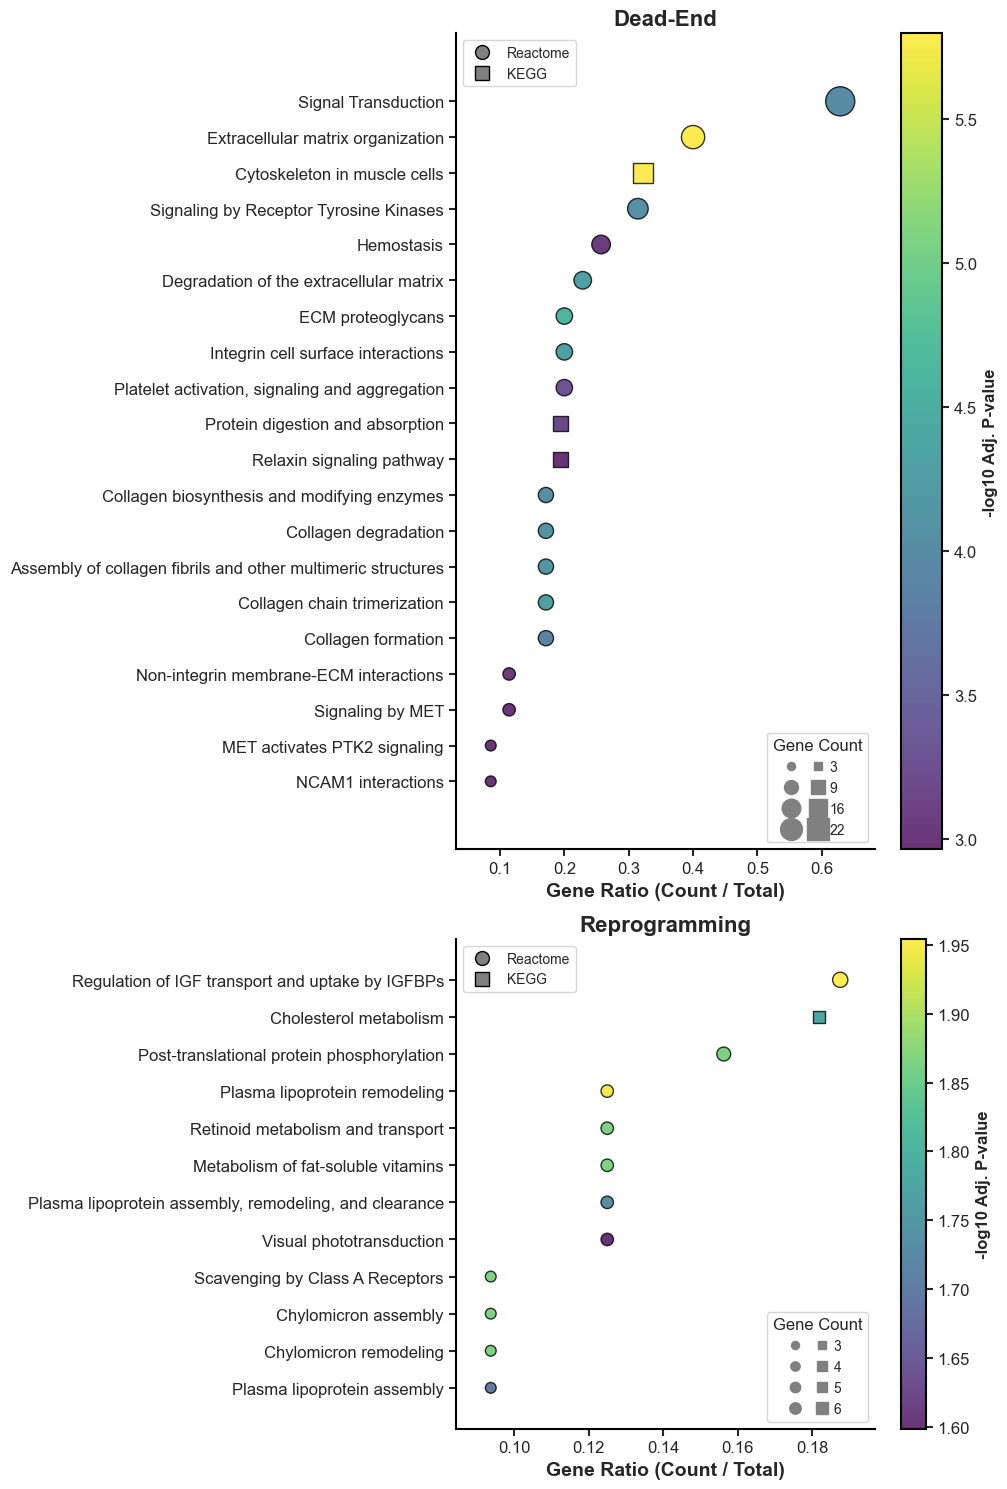

In [36]:
def preprocess_file(df, splitter):

    
    df['Term'] = df['Term'].str.split(splitter).str[-1]
    if splitter == "-":
        df['Term'] = df['Term'].str.split("~").str[-1]
    
    df = df[df['Benjamini'] < 0.05].copy()
    
    df['Gene Ratio'] = df['Count'] / df['List Total']
    return df

def plot_gene_ratio_bubble_merged(dead_end_df, reprogramming_df, title):

    marker_shapes = {"Reactome": "o", "KEGG": "s"}
    n_dead_end = len(dead_end_df) if not dead_end_df.empty else 1
    n_reprogramming = len(reprogramming_df) if not reprogramming_df.empty else 1
    fig, axes = plt.subplots(2, 1, figsize=(10, 15), gridspec_kw={'height_ratios': [n_dead_end, n_reprogramming]})
    for ax, (df, condition) in zip(axes, [(dead_end_df, "Dead-End"), (reprogramming_df, "Reprogramming")]):
        if df.empty:
            ax.text(0.5, 0.5, "No Significant Pathways", fontsize=14, ha='center')
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        df = df.copy()
        df['Display_Term'] = df['Term']
        df = df.sort_values(by='Gene Ratio', ascending=False).reset_index(drop=True)
        df['y_pos'] = df.index
        scatter_obj = None
        for lib, marker in marker_shapes.items():
            subset = df[df['Library'] == lib]
            if not subset.empty:
                scatter_obj = ax.scatter(subset['Gene Ratio'], subset['y_pos'], s=subset['Count'] * 20, c=-np.log10(subset['Benjamini']), cmap='viridis', alpha=0.8, edgecolors='black', marker=marker, label=lib)
        ax.set_xlabel('Gene Ratio (Count / Total)', fontsize=14)
        ax.set_title(f"{condition}", fontsize=16)
        ax.set_yticks(df['y_pos'])
        ax.set_yticklabels(df['Display_Term'], fontsize=12)
        ax.invert_yaxis()
        if not df['Gene Ratio'].empty:
            min_x, max_x = df['Gene Ratio'].min(), df['Gene Ratio'].max()
            padding = (max_x - min_x) * 0.1 if (max_x - min_x) > 0 else 0.1
            ax.set_xlim(min_x - padding, max_x + padding)
        ax.margins(y=0.1, x=0.15)
        if scatter_obj is not None:
            cbar = fig.colorbar(scatter_obj, ax=ax)
            cbar.set_label('-log10 Adj. P-value', fontsize=12)
        min_count = df['Count'].min()
        max_count = df['Count'].max()
        if min_count == max_count:
            legend_counts = [min_count]
        else:
            legend_counts = np.linspace(min_count, max_count, 4)
            legend_counts = [int(round(x)) for x in legend_counts]
        class HandlerDualMarker(HandlerBase):
            def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):
                cx = x0 + width/2 
                cy = y0 + height/2
                offset = width/2
                offset_y = height/5
                size = np.sqrt(orig_handle['size']) * 0.75
                a1 = plt.Line2D([cx - offset], [cy], marker=orig_handle['marker1'], color='gray', markerfacecolor='gray', markersize=size, linestyle='')
                a2 = plt.Line2D([cx + offset], [cy], marker=orig_handle['marker2'], color='gray', markerfacecolor='gray', markersize=size, linestyle='')
                return [a1, a2]
        dummy_handles = []
        for count in legend_counts:
            dummy_handles.append({'marker1': 'o', 'marker2': 's', 'size': count * 20})
        size_legend = ax.legend(dummy_handles, [str(x) for x in legend_counts], title='Gene Count', loc='lower right', frameon=True, fontsize=10, title_fontsize=12, handler_map={dict: HandlerDualMarker()})
        ax.add_artist(size_legend)
        lib_handles = []
        for lib, marker in marker_shapes.items():
            lib_handles.append(plt.Line2D([], [], marker=marker, color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label=lib))
        ax.legend(handles=lib_handles, loc='upper left', frameon=True, fontsize=10, title_fontsize=12)
    plt.tight_layout()
    plt.show()


reactome_dead_end = de_all[de_all["Category"] == "REACTOME_PATHWAY"]
reactome_reprogramming = re_all[re_all["Category"] == "REACTOME_PATHWAY"]
kegg_dead_end = de_all[de_all["Category"] == "KEGG_PATHWAY"]
kegg_reprogramming = re_all[re_all["Category"] == "KEGG_PATHWAY"]

reactome_dead_end_data = preprocess_file(reactome_dead_end, "~")
reactome_dead_end_data["Library"] = "Reactome"
reactome_reprogramming_data = preprocess_file(reactome_reprogramming, "~")
reactome_reprogramming_data["Library"] = "Reactome"

kegg_dead_end_data = preprocess_file(kegg_dead_end, ":")
kegg_dead_end_data["Library"] = "KEGG"
kegg_reprogramming_data = preprocess_file(kegg_reprogramming, ":")
kegg_reprogramming_data["Library"] = "KEGG"

merged_dead_end = pd.concat([reactome_dead_end_data, kegg_dead_end_data], ignore_index=True)
merged_reprogramming = pd.concat([reactome_reprogramming_data, kegg_reprogramming_data], ignore_index=True)

dataset_name = "Merged Reactome & KEGG Pathway Enrichment"

plot_gene_ratio_bubble_merged(
    merged_dead_end,
    merged_reprogramming,
    dataset_name,
)

<Figure size 640x480 with 0 Axes>

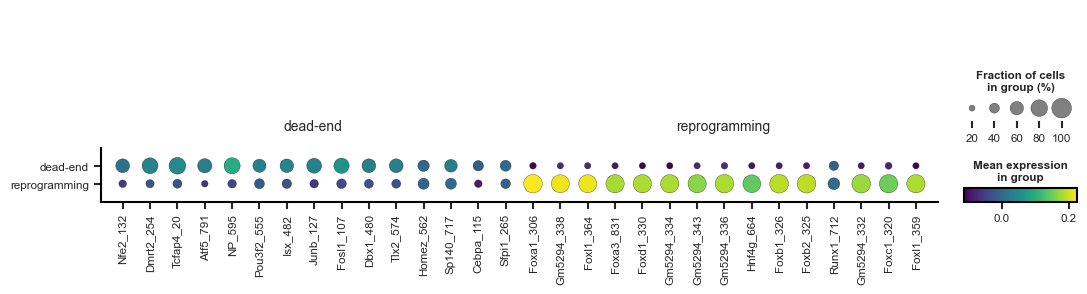

In [37]:

top_atac_markers = df_features[df_features['modality'] == 'ATAC']
de_top = top_atac_markers[top_atac_markers['group'] == 'dead-end'].sort_values(by='mean_rank').head(15)['feature'].tolist()
de_vals = top_atac_markers[top_atac_markers['group'] == 'dead-end'].sort_values(by='mean_rank').head(15)['mean_rank'].tolist()
re_top = top_atac_markers[top_atac_markers['group'] == 'reprogramming'].sort_values(by='mean_rank').head(15)['feature'].tolist()
re_vals = top_atac_markers[top_atac_markers['group'] == 'reprogramming'].sort_values(by='mean_rank').head(15)['mean_rank'].tolist()
marker_tf_dict = {
    "dead-end": de_top,
    "reprogramming": re_top
}

rank_genes_groups = {'names': {}, 'logfoldchanges': {}, 'pvals': {}, 'pvals_adj': {}, 'scores': {}}
rank_genes_groups['names'] = top_atac_markers['feature'].values
rank_genes_groups['logfoldchanges'] = top_atac_markers['log_fc'].values

scaled_atac = adata_ATAC_labelled.copy()
plt.figure()
dotplot = sc.pl.dotplot(scaled_atac, marker_tf_dict, groupby='label', cmap='viridis', show=False, use_raw=False, var_group_rotation=0)
plt.show()
plt.close() 

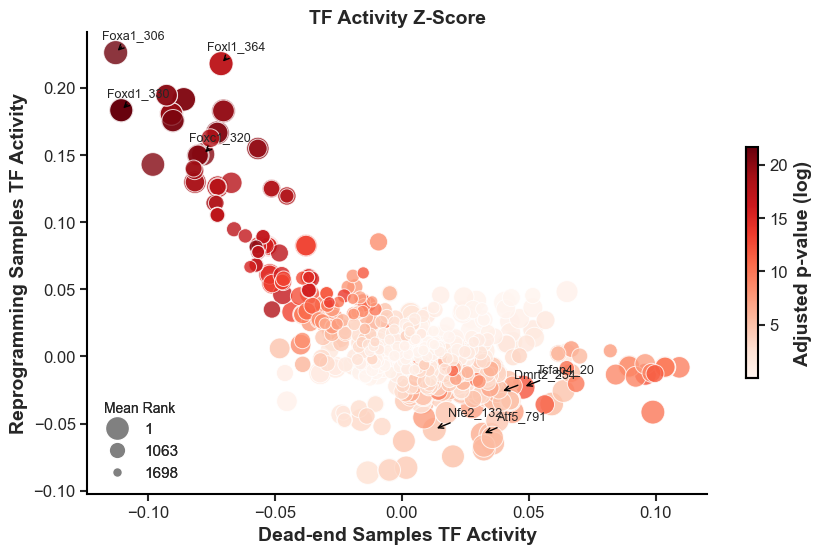

In [38]:
max_rank = atac_combined_df['mean_rank'].max()
atac_combined_df['inverse_rank'] = max_rank - atac_combined_df['mean_rank']
p = "Reds"

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=atac_combined_df, x='mean_de', y='mean_re',
    size='inverse_rank', hue='pval_adj_log',
    sizes=(50, 300), palette=p,
    alpha=0.8, edgecolor='w', rasterized=True,
    legend=False
)

norm = plt.Normalize(
    atac_combined_df['pval_adj_log'].min(),
    atac_combined_df['pval_adj_log'].max()
)
sm = plt.cm.ScalarMappable(cmap=p, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, shrink=0.5)
cbar.set_label('Adjusted p-value (log)')

inv_min = atac_combined_df['inverse_rank'].min()
inv_max = atac_combined_df['inverse_rank'].max()
size_min, size_max = 50, 300

def map_size(inv):
    return ((inv - inv_min) / (inv_max - inv_min)) * (size_max - size_min) + size_min

actual_min = atac_combined_df['mean_rank'].min()
actual_med = np.median(atac_combined_df['mean_rank'])
actual_max = atac_combined_df['mean_rank'].max()

inv_for_min = max_rank - actual_min
inv_for_med = max_rank - actual_med
inv_for_max = max_rank - actual_max

size_val_min = map_size(inv_for_min)
size_val_med = map_size(inv_for_med)
size_val_max = map_size(inv_for_max)

legend_handles = [
    Line2D([], [], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(size_val_min), label=f"{int(actual_min)}"),
    Line2D([], [], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(size_val_med), label=f"{int(actual_med)}"),
    Line2D([], [], marker='o', color='w', markerfacecolor='gray',
           markersize=np.sqrt(size_val_max), label=f"{int(actual_max)}")
]

size_legend = ax.legend(handles=legend_handles, title="Mean Rank", loc="lower left")
ax.add_artist(size_legend)

dead_end_top = atac_combined_df[atac_combined_df['group'] == 'dead-end'].nsmallest(4, 'mean_rank')
dead_end_top = ['Nfe2_132', 'Dmrt2_254', 'Tcfap4_20', 'Atf5_791']
reprogramming_top = atac_combined_df[atac_combined_df['group'] == 'reprogramming'].nsmallest(4, 'mean_rank')
reprogramming_top = ['Foxa1_306', 'Foxc1_320', 'Foxd1_330', 'Foxl1_364']
for f in dead_end_top:
    row = atac_combined_df[atac_combined_df['feature'] == f]
    ax.annotate(
        row['feature'].tolist()[0],
        xy=(row['mean_de'], row['mean_re']),
        xytext=(10, 10), textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='black'),
        fontsize=9
    )

for f in reprogramming_top:
    row = atac_combined_df[atac_combined_df['feature'] == f]
    ax.annotate(
        row['feature'].tolist()[0],
        xy=(row['mean_de'], row['mean_re']),
        xytext=(-10, 10), textcoords='offset points',
        arrowprops=dict(arrowstyle="->", color='black'),
        fontsize=9
    )

plt.xlabel("Dead-end Samples TF Activity")
plt.ylabel("Reprogramming Samples TF Activity")
plt.title("TF Activity Z-Score")
sns.despine()

plt.show()


TF Heatmaps (9, 2)            Dead-end  Reprogramming
feature                           
Foxa1_306 -0.112726       0.226130
Foxc1_320 -0.078247       0.150447
Foxd1_330 -0.110524       0.183258
Foxl1_364 -0.071203       0.217929
NP_595     0.098921      -0.041456
Tcfap4_20  0.047740      -0.022908
Atf5_791   0.031711      -0.057887
Dmrt2_254  0.038894      -0.026386
Fosl1_107  0.059068      -0.035410
Gene Expression Heatmap (9, 2) group  dead-end  reprogramming
Foxa1  0.018206       0.030524
Foxc1  0.049399       0.070757
Foxd1  0.027121       0.031040
Foxl1  0.001848       0.002757
Pnp    0.322281       0.371609
Tfap4  0.026138       0.025543
Atf5   0.477394       0.213573
Dmrt2  0.002629       0.003614
Fosl1  0.077360       0.066654


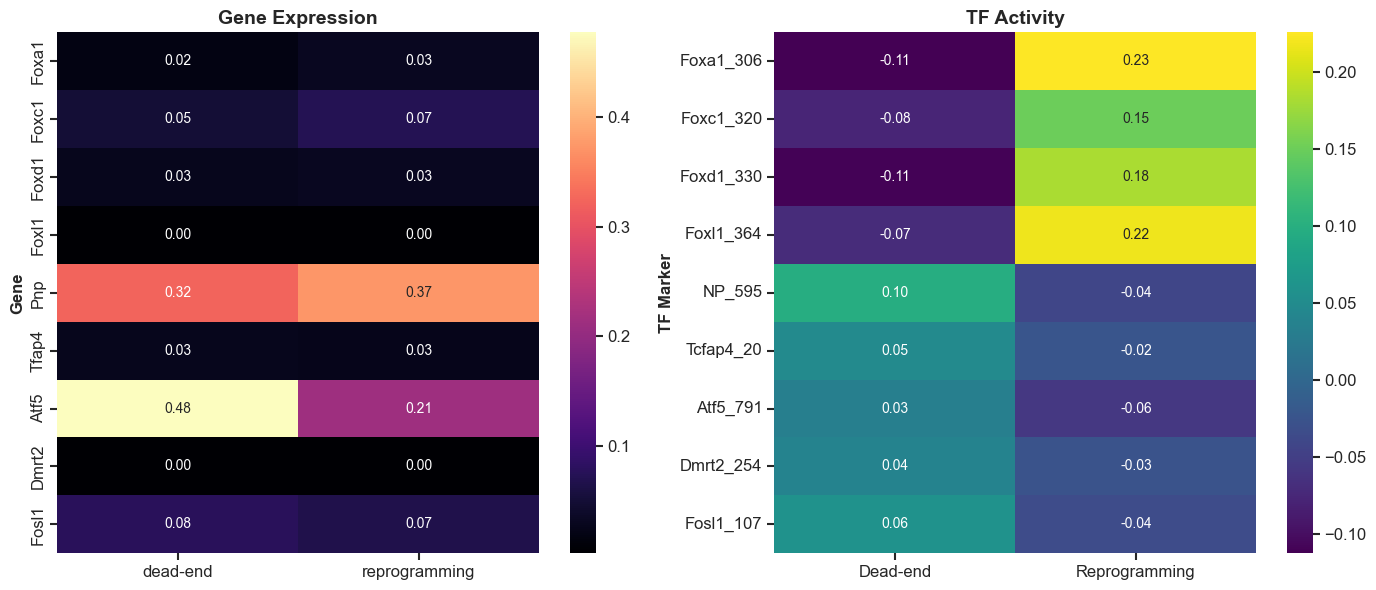

In [39]:
with open('data/datasets/rna_labelled_all.pkl', 'rb') as f:
    adata_RNA_labelled_all = pickle.load(f)

atac_df = atac_combined_df.copy()
top_tfs = ['Foxa1_306', 'Foxc1_320', 'Foxd1_330', 'Foxl1_364', 'NP_595', 'Tcfap4_20', 'Atf5_791', 'Dmrt2_254', 'Fosl1_107']
top_tf_genes = ['Foxa1', 'Foxc1', 'Foxd1', 'Foxl1', 'Pnp', 'Tfap4', 'Atf5', 'Dmrt2', 'Fosl1']

top_atac = atac_df[atac_df['feature'].isin(top_tfs)].set_index('feature')
atac_heatmap = top_atac[['mean_de', 'mean_re']].rename(columns={'mean_de':'Dead-end', 'mean_re':'Reprogramming'})
atac_heatmap = atac_heatmap.loc[top_tfs]

rna_data = adata_RNA_labelled_all
adata_subset = rna_data[:, top_tf_genes]
if hasattr(adata_subset.X, "toarray"):
    expr_data = adata_subset.X.toarray()
else:
    expr_data = adata_subset.X
expr_df = pd.DataFrame(expr_data, columns=adata_subset.var_names, index=adata_subset.obs_names)
expr_df['group'] = adata_subset.obs['label'].values
expr_group_mean = expr_df.groupby('group').mean().T
expr_group_mean = expr_group_mean.loc[top_tf_genes]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax0, ax1 = axes

sns.heatmap(expr_group_mean, annot=True, cmap='magma', fmt=".2f", ax=ax0)
ax0.set_title("Gene Expression", fontsize=14)
ax0.set_ylabel("Gene", fontsize=12)
ax0.set_xlabel("")

sns.heatmap(atac_heatmap, annot=True, cmap='viridis', fmt=".2f", ax=ax1)
ax1.set_title("TF Activity", fontsize=14)
ax1.set_ylabel("TF Marker", fontsize=12)
ax1.set_xlabel("")

print("TF Heatmaps", atac_heatmap.shape, atac_heatmap)
print("Gene Expression Heatmap", expr_group_mean.shape, expr_group_mean)
plt.tight_layout()
plt.show()
